In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df['Sales'].min()


np.float64(22638.48)

In [ ]:
df.groupby(['Category']).agg(
    mean_2019 = ('Sales', 'mean'),
    std_2019 = ('Sales', 'std'),
    mean_2020 = ('profit', 'mean'),
    std_2020 = ('profit', 'std')
)

KeyError: "Column(s) ['profit'] do not exist"

In [10]:
df['Sales'].max()

np.float64(22638.48)

In [6]:
df2 = df.drop(columns=['Order ID','Customer ID','Customer Name', 'Product ID', 'Postal Code','Product Name'], axis=1)

In [7]:
df2.dtypes

Row ID            int64
Order Date       object
Ship Date        object
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [8]:
df2['New_Sales'] = np.floor(df['Sales'] * 100) / 100
df2

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,New_Sales
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,261.95
1,2,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,731.94
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,14.62
3,4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,957.57
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,22.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,1/21/2014,1/23/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,25.24
9990,9991,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,91.96
9991,9992,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones,258.5760,2,0.20,19.3932,258.57
9992,9993,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,29.60


In [9]:
df2['New_Profit'] = np.floor(df['Profit'] * 100) /100
df2

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,New_Sales,New_Profit
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,261.95,41.91
1,2,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,731.94,219.58
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,14.62,6.87
3,4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,957.57,-383.04
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,22.36,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,1/21/2014,1/23/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,25.24,4.10
9990,9991,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,91.96,15.63
9991,9992,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones,258.5760,2,0.20,19.3932,258.57,19.39
9992,9993,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,29.60,13.32


<Axes: xlabel='New_Sales', ylabel='Count'>

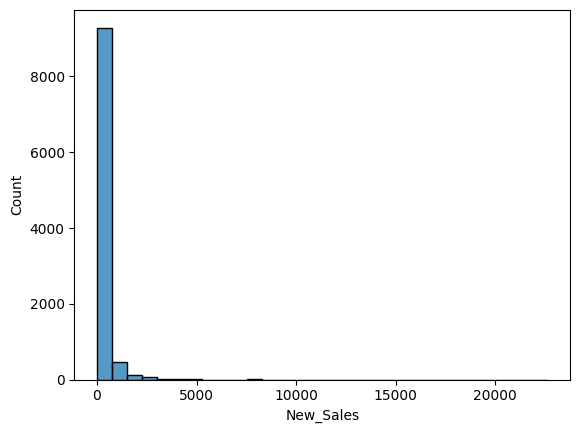

In [10]:
sns.histplot(x='New_Sales',bins=30 , data=df2)

In [11]:
df2.describe()

,Row ID,Sales,Quantity,Discount,Profit,New_Sales,New_Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896,229.855611,28.652281
std,2885.163629,623.245101,2.225110,0.206452,234.260108,623.245153,234.260131
min,1.000000,0.444000,1.000000,0.000000,-6599.978000,0.440000,-6599.980000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750,17.280000,1.722500
50%,4997.500000,54.490000,3.000000,0.200000,8.666500,54.490000,8.665000
75%,7495.750000,209.940000,5.000000,0.200000,29.364000,209.940000,29.360000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000,22638.480000,8399.970000


In [12]:
Update_df = df2.drop(columns=['Sales','Profit'])
Update_df


,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Quantity,Discount,New_Sales,New_Profit
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,2,0.00,261.95,41.91
1,2,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,3,0.00,731.94,219.58
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,2,0.00,14.62,6.87
3,4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,5,0.45,957.57,-383.04
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,2,0.20,22.36,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,1/21/2014,1/23/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,3,0.20,25.24,4.10
9990,9991,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings,2,0.00,91.96,15.63
9991,9992,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones,2,0.20,258.57,19.39
9992,9993,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Office Supplies,Paper,4,0.00,29.60,13.32


In [13]:
Update_df

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Quantity,Discount,New_Sales,New_Profit
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,2,0.00,261.95,41.91
1,2,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,3,0.00,731.94,219.58
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,2,0.00,14.62,6.87
3,4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,5,0.45,957.57,-383.04
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,2,0.20,22.36,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,1/21/2014,1/23/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,3,0.20,25.24,4.10
9990,9991,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings,2,0.00,91.96,15.63
9991,9992,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones,2,0.20,258.57,19.39
9992,9993,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Office Supplies,Paper,4,0.00,29.60,13.32


In [14]:
Update_df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

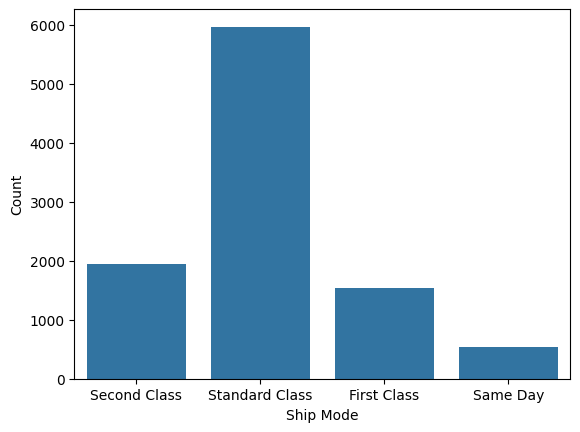

In [15]:
sns.countplot(x='Ship Mode', data=Update_df)
plt.xlabel('Ship Mode')
plt.ylabel('Count')
plt.show()

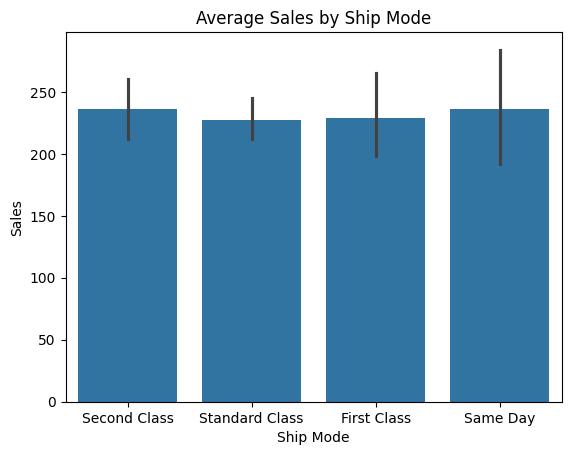

In [16]:
sns.barplot(x='Ship Mode', y='New_Sales', data=Update_df)
plt.xlabel('Ship Mode')
plt.ylabel('Sales')
plt.title('Average Sales by Ship Mode')
plt.show()

Segment

In [17]:
Update_df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

<Axes: xlabel='Segment', ylabel='count'>

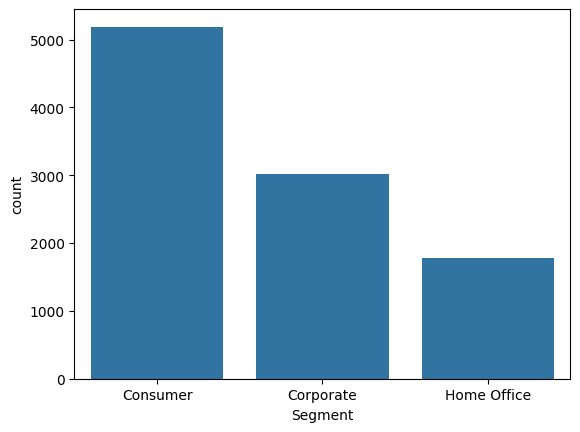

In [18]:
sns.countplot(x='Segment', data=Update_df)

Text(0.5, 1.0, 'Average Sales by Segment')

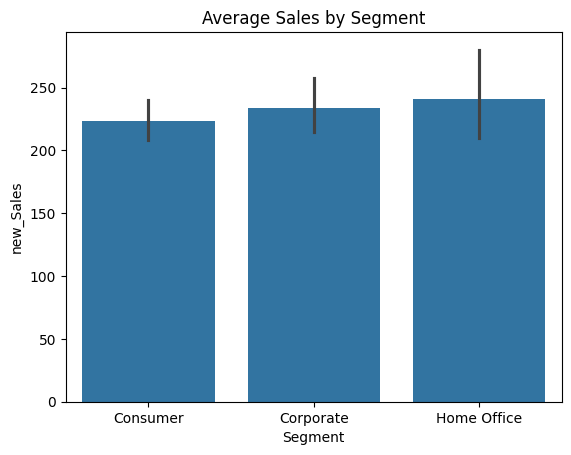

In [19]:
sns.barplot(x='Segment', y='New_Sales', data=Update_df)
plt.xlabel('Segment')
plt.ylabel('new_Sales')
plt.title('Average Sales by Segment')


In [20]:
Update_df['Country'].unique()

array(['United States'], dtype=object)

In [21]:
Update_df['City'].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

In [22]:
Update_df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [23]:
Update_df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

<Axes: xlabel='Region', ylabel='count'>

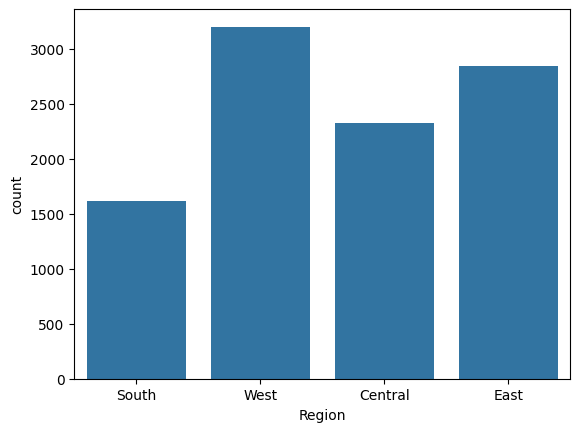

In [24]:
sns.countplot(x='Region',data=Update_df)

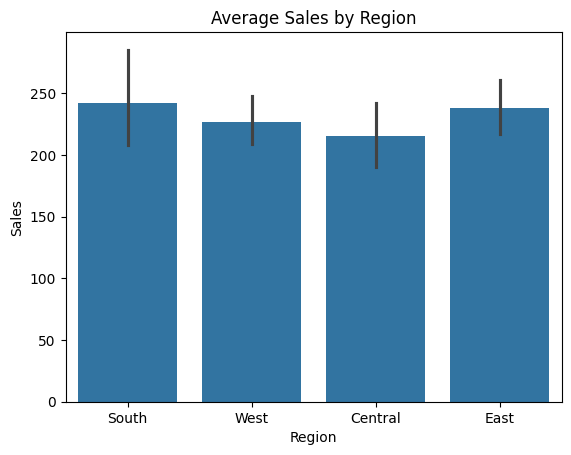

In [25]:
sns.barplot(x='Region', y='New_Sales', data=Update_df)
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Average Sales by Region')
plt.show()

In [26]:
Update_df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

<Axes: xlabel='Category', ylabel='count'>

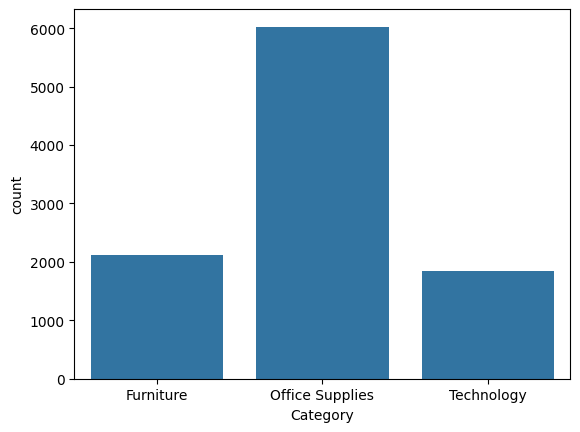

In [27]:
sns.countplot(x='Category', data=Update_df)

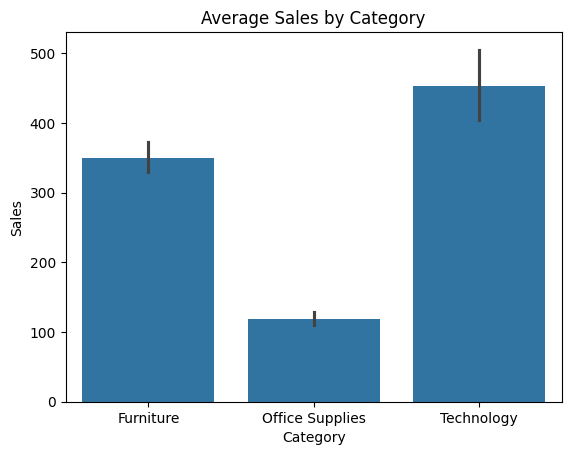

In [28]:
sns.barplot(x='Category', y='New_Sales', data=Update_df)
plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Average Sales by Category')
plt.show()

Text(0.5, 1.0, 'Box Plot')

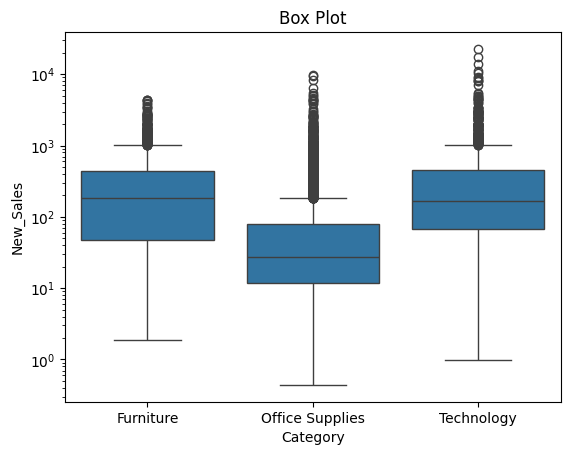

In [29]:
sns.boxplot(x='Category', y='New_Sales', data=Update_df)
plt.yscale('log')
plt.title('Box Plot')

In [30]:
# هذا الكود خطأ تكتبه بسبب اني سويت كلين زيادة عن اللزوم
# Dataf =  Update_df[Update_df['New_Sales'] < 2000]  
# Dataf


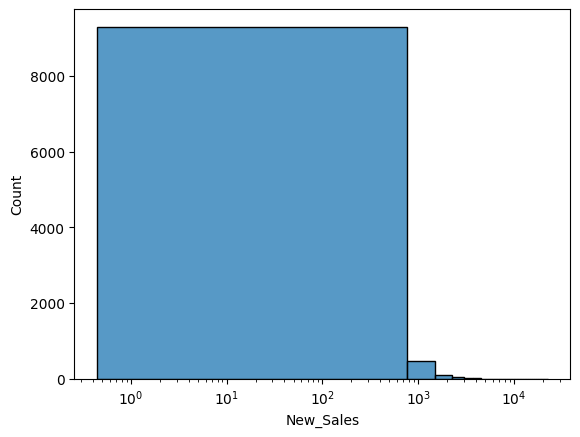

In [31]:
sns.histplot(x='New_Sales', bins=30 ,data=Update_df)
plt.xscale('log')

<Axes: xlabel='New_Sales', ylabel='New_Sales'>

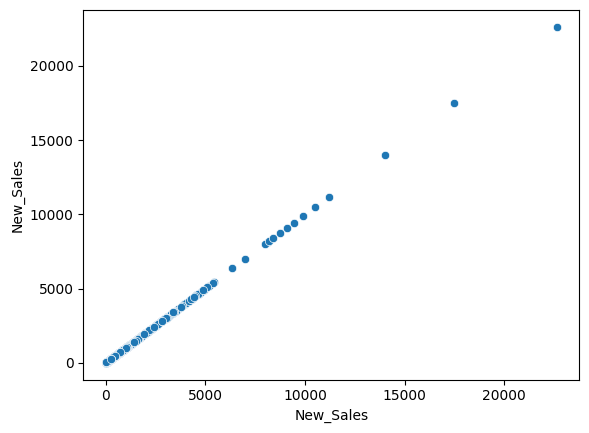

In [32]:
sns.scatterplot(x='New_Sales', y='New_Sales', data=Update_df)

(0.0, 10000.0)

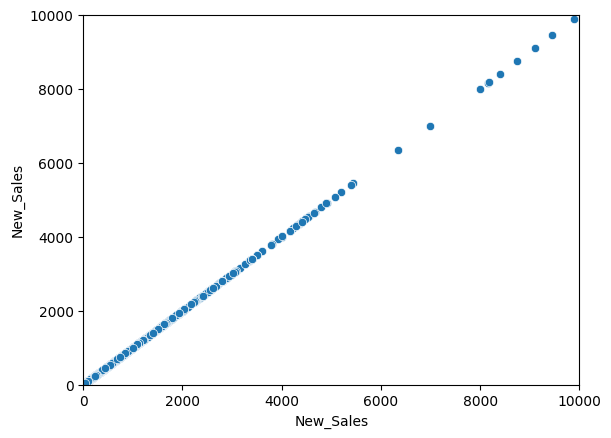

In [33]:
sns.scatterplot(x='New_Sales', y='New_Sales', data=Update_df)
plt.xlim(0, 10000)
plt.ylim(0, 10000)


(0.0, 9000.0)

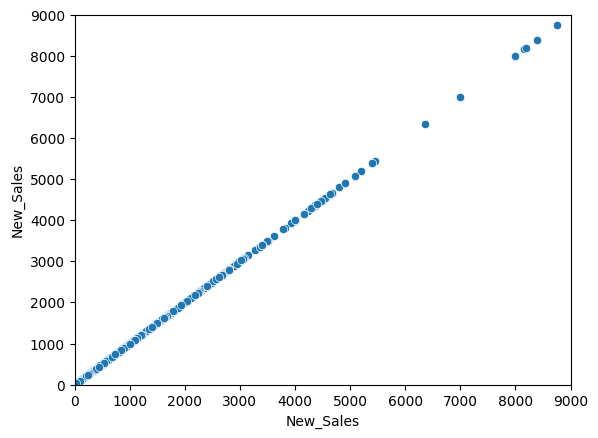

In [34]:
sns.scatterplot(x='New_Sales', y='New_Sales', data=Update_df)
plt.xlim(0, 9000)
plt.ylim(0, 9000)

In [35]:
Update_df.shape # the mix Sales 22638.00
Update_df.shape

(9994, 15)

In [36]:
filtered_df = Update_df[Update_df['New_Sales'] < 500] # the max sales 499.99
filtered_df.max()
# filtered_df.shape

Row ID                    9994
Order Date            9/9/2017
Ship Date             9/9/2017
Ship Mode       Standard Class
Segment            Home Office
Country          United States
City                      Yuma
State                Wisconsin
Region                    West
Category            Technology
Sub-Category            Tables
Quantity                    14
Discount                   0.8
New_Sales               499.99
New_Profit              240.85
dtype: object

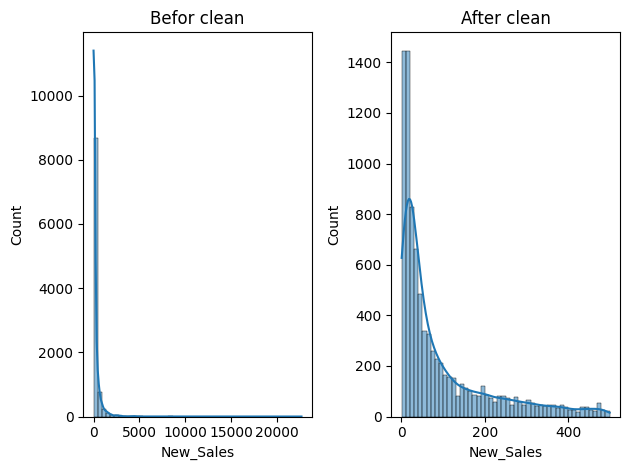

In [37]:
plt.Figure(figsize=(16,8))

plt.subplot(1,2,1)
sns.histplot(x=Update_df['New_Sales'], bins=50, kde=True)
plt.title('Befor clean')

plt.subplot(1,2,2)
sns.histplot(x=filtered_df['New_Sales'], bins=50, kde=True)
plt.title('After clean')

plt.tight_layout()
plt.show()

In [38]:
Update_df['New_Sales'].quantile([0.90,0.95,0.99,0.999])

0.900     572.70600
0.950     956.97850
0.990    2481.69390
0.999    8189.13624
Name: New_Sales, dtype: float64

In [39]:
Update_df.describe()

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,3.789574,0.156203,229.855611,28.652281
std,2885.163629,2.225110,0.206452,623.245153,234.260131
min,1.000000,1.000000,0.000000,0.440000,-6599.980000
25%,2499.250000,2.000000,0.000000,17.280000,1.722500
50%,4997.500000,3.000000,0.200000,54.490000,8.665000
75%,7495.750000,5.000000,0.200000,209.940000,29.360000
max,9994.000000,14.000000,0.800000,22638.480000,8399.970000


In [40]:
filtered_df.describe()

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,8832.000000,8832.000000,8832.000000,8832.000000,8832.000000
mean,5016.160553,3.608243,0.157562,93.092808,11.243726
std,2888.110004,2.129020,0.211492,114.422793,49.113545
min,1.000000,1.000000,0.000000,0.440000,-1181.290000
25%,2508.750000,2.000000,0.000000,15.015000,1.700000
50%,5027.500000,3.000000,0.200000,40.965000,7.450000
75%,7517.250000,5.000000,0.200000,124.370000,21.405000
max,9994.000000,14.000000,0.800000,499.990000,240.850000


In [41]:
rows_lost = len(Update_df) - len(filtered_df)
percent_lost = (rows_lost / len(Update_df)) * 100
print(f'= {percent_lost:.2f}%')

= 11.63%


In [42]:
coutoff90 = Update_df['New_Sales'].quantile(0.90)
df_after_coutoff_90 = Update_df[Update_df['New_Sales']< coutoff90]
df_after_coutoff_90.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        8994 non-null   int64  
 1   Order Date    8994 non-null   object 
 2   Ship Date     8994 non-null   object 
 3   Ship Mode     8994 non-null   object 
 4   Segment       8994 non-null   object 
 5   Country       8994 non-null   object 
 6   City          8994 non-null   object 
 7   State         8994 non-null   object 
 8   Region        8994 non-null   object 
 9   Category      8994 non-null   object 
 10  Sub-Category  8994 non-null   object 
 11  Quantity      8994 non-null   int64  
 12  Discount      8994 non-null   float64
 13  New_Sales     8994 non-null   float64
 14  New_Profit    8994 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 1.1+ MB


In [43]:
coutoff = Update_df['New_Sales'].quantile(0.95)
df_after_coutoff_95 = Update_df[Update_df['New_Sales']< coutoff]
df_after_coutoff_95.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9494 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9494 non-null   int64  
 1   Order Date    9494 non-null   object 
 2   Ship Date     9494 non-null   object 
 3   Ship Mode     9494 non-null   object 
 4   Segment       9494 non-null   object 
 5   Country       9494 non-null   object 
 6   City          9494 non-null   object 
 7   State         9494 non-null   object 
 8   Region        9494 non-null   object 
 9   Category      9494 non-null   object 
 10  Sub-Category  9494 non-null   object 
 11  Quantity      9494 non-null   int64  
 12  Discount      9494 non-null   float64
 13  New_Sales     9494 non-null   float64
 14  New_Profit    9494 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 1.2+ MB


In [44]:
df_after_coutoff_90.describe()

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,8994.000000,8994.000000,8994.000000,8994.000000,8994.000000
mean,5014.357905,3.624305,0.157373,101.093823,11.676309
std,2884.187232,2.136807,0.210680,127.886117,51.544593
min,1.000000,1.000000,0.000000,0.440000,-1181.290000
25%,2510.500000,2.000000,0.000000,15.432500,1.670000
50%,5027.500000,3.000000,0.200000,42.600000,7.500000
75%,7510.500000,5.000000,0.200000,135.780000,22.070000
max,9994.000000,14.000000,0.800000,572.580000,274.990000


In [45]:
coutoof = Update_df['New_Sales'].quantile(0.99)  #
df_after_coutoff_99 = Update_df[Update_df['New_Sales']< coutoof]
df_after_coutoff_99.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9894 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9894 non-null   int64  
 1   Order Date    9894 non-null   object 
 2   Ship Date     9894 non-null   object 
 3   Ship Mode     9894 non-null   object 
 4   Segment       9894 non-null   object 
 5   Country       9894 non-null   object 
 6   City          9894 non-null   object 
 7   State         9894 non-null   object 
 8   Region        9894 non-null   object 
 9   Category      9894 non-null   object 
 10  Sub-Category  9894 non-null   object 
 11  Quantity      9894 non-null   int64  
 12  Discount      9894 non-null   float64
 13  New_Sales     9894 non-null   float64
 14  New_Profit    9894 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 1.2+ MB


In [46]:
df_after_coutoff_99.describe() #0.99

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,9894.000000,9894.000000,9894.000000,9894.000000,9894.000000
mean,4994.175662,3.765616,0.156473,186.389834,20.048427
std,2883.394648,2.208377,0.206844,323.606131,120.849873
min,1.000000,1.000000,0.000000,0.440000,-3701.900000
25%,2496.250000,2.000000,0.000000,17.042500,1.710000
50%,4990.500000,3.000000,0.200000,52.575000,8.490000
75%,7487.750000,5.000000,0.200000,201.025000,28.505000
max,9994.000000,14.000000,0.800000,2479.960000,1114.510000


In [47]:
df_after_coutoff_95.describe() # 0.95

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,9494.000000,9494.000000,9494.000000,9494.000000,9494.000000
mean,5006.001053,3.682115,0.157290,134.371817,14.203656
std,2880.740310,2.154777,0.208206,189.871465,69.891235
min,1.000000,1.000000,0.000000,0.440000,-1480.040000
25%,2515.250000,2.000000,0.000000,16.005000,1.670000
50%,5001.500000,3.000000,0.200000,47.900000,7.980000
75%,7499.750000,5.000000,0.200000,168.950000,24.880000
max,9994.000000,14.000000,0.800000,956.660000,421.580000


In [48]:
df_after_coutoff_90.describe() # 0.90

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,8994.000000,8994.000000,8994.000000,8994.000000,8994.000000
mean,5014.357905,3.624305,0.157373,101.093823,11.676309
std,2884.187232,2.136807,0.210680,127.886117,51.544593
min,1.000000,1.000000,0.000000,0.440000,-1181.290000
25%,2510.500000,2.000000,0.000000,15.432500,1.670000
50%,5027.500000,3.000000,0.200000,42.600000,7.500000
75%,7510.500000,5.000000,0.200000,135.780000,22.070000
max,9994.000000,14.000000,0.800000,572.580000,274.990000


<Axes: xlabel='Sub-Category', ylabel='New_Sales'>

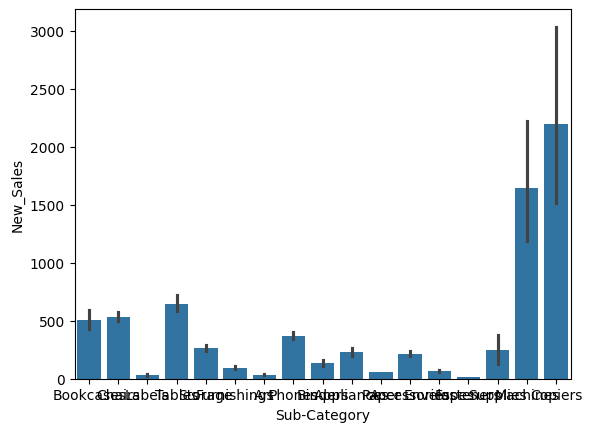

In [49]:
sns.barplot(x='Sub-Category', y='New_Sales', data=Update_df)

<Axes: xlabel='Sub-Category', ylabel='count'>

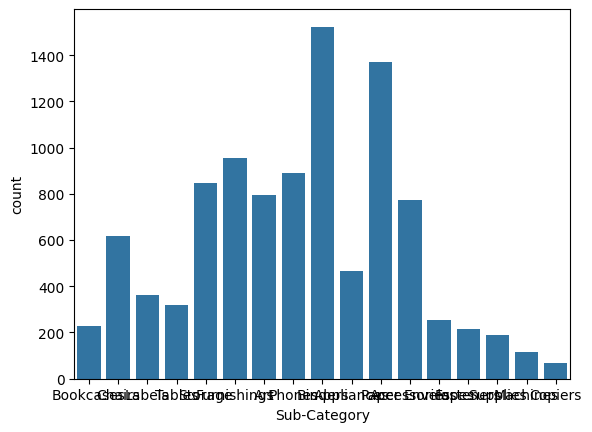

In [50]:
sns.countplot(x='Sub-Category', data=Update_df)

<Axes: xlabel='Sub-Category', ylabel='New_Sales'>

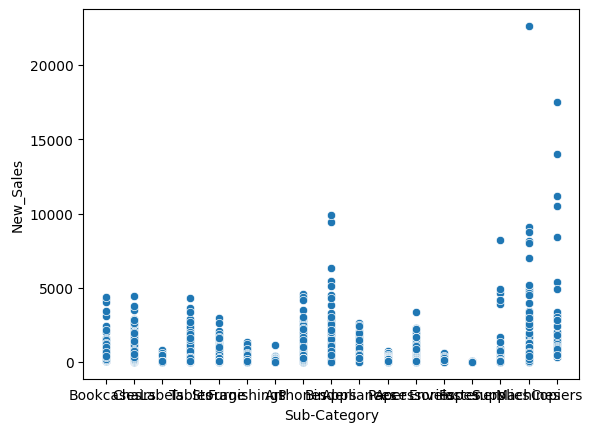

In [51]:
sns.scatterplot(x='Sub-Category', y='New_Sales', data=Update_df)

In [52]:
Update_df['Quantity'].unique()

array([ 2,  3,  5,  7,  4,  6,  9,  1,  8, 14, 11, 13, 10, 12])

<Axes: xlabel='Quantity', ylabel='New_Sales'>

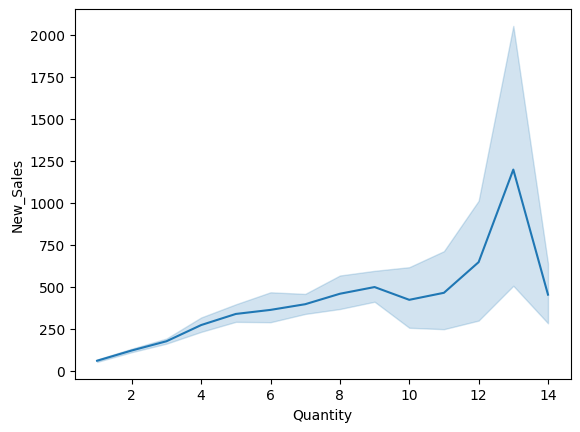

In [53]:
sns.lineplot(x='Quantity',y='New_Sales',data=Update_df)

<Axes: xlabel='Quantity', ylabel='count'>

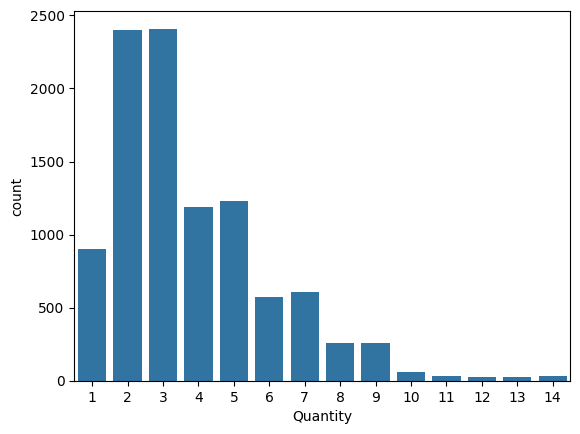

In [54]:
sns.countplot(x='Quantity', data=Update_df)

<Axes: xlabel='Quantity', ylabel='New_Sales'>

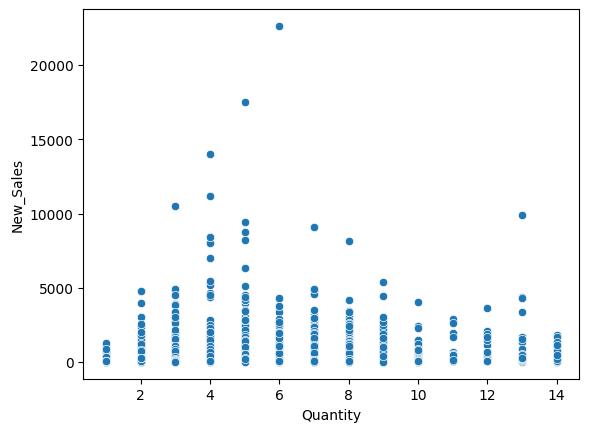

In [55]:
sns.scatterplot(x='Quantity', y='New_Sales', data=Update_df)

<Axes: xlabel='Order Date', ylabel='New_Sales'>

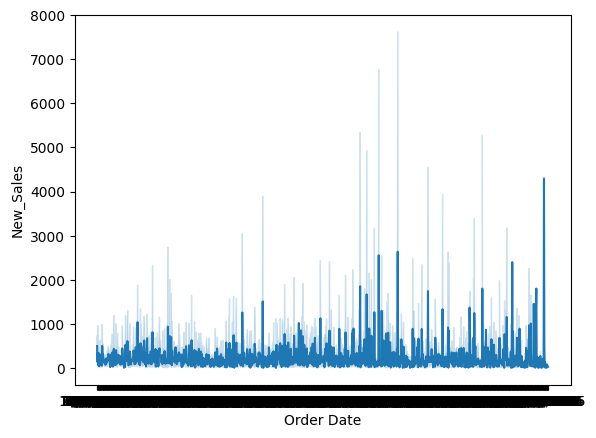

In [56]:
sns.lineplot(x='Order Date', y='New_Sales', data=Update_df)

In [57]:
# daily_sales = Update_df.set_index('Order Date').resample('D').size()
# rolling_sales = daily_sales.rolling(30).mean()
# sns.lineplot(x='rolling_sales', y='New_Sales', data=Update_df)

In [58]:
# sns.histplot(df['New_Sales'], bins=50,kde=True)
# plt.xscale('log')
# plt.xlabel('New_Sales (log scale)')
# plt.show()

In [59]:
df_after_coutoff_95.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9494 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9494 non-null   int64  
 1   Order Date    9494 non-null   object 
 2   Ship Date     9494 non-null   object 
 3   Ship Mode     9494 non-null   object 
 4   Segment       9494 non-null   object 
 5   Country       9494 non-null   object 
 6   City          9494 non-null   object 
 7   State         9494 non-null   object 
 8   Region        9494 non-null   object 
 9   Category      9494 non-null   object 
 10  Sub-Category  9494 non-null   object 
 11  Quantity      9494 non-null   int64  
 12  Discount      9494 non-null   float64
 13  New_Sales     9494 non-null   float64
 14  New_Profit    9494 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 1.2+ MB


In [60]:
df_cleaned = df_after_coutoff_95

In [61]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9494 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9494 non-null   int64  
 1   Order Date    9494 non-null   object 
 2   Ship Date     9494 non-null   object 
 3   Ship Mode     9494 non-null   object 
 4   Segment       9494 non-null   object 
 5   Country       9494 non-null   object 
 6   City          9494 non-null   object 
 7   State         9494 non-null   object 
 8   Region        9494 non-null   object 
 9   Category      9494 non-null   object 
 10  Sub-Category  9494 non-null   object 
 11  Quantity      9494 non-null   int64  
 12  Discount      9494 non-null   float64
 13  New_Sales     9494 non-null   float64
 14  New_Profit    9494 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 1.2+ MB


In [62]:
df_cleaned.describe()

,Row ID,Quantity,Discount,New_Sales,New_Profit
count,9494.000000,9494.000000,9494.000000,9494.000000,9494.000000
mean,5006.001053,3.682115,0.157290,134.371817,14.203656
std,2880.740310,2.154777,0.208206,189.871465,69.891235
min,1.000000,1.000000,0.000000,0.440000,-1480.040000
25%,2515.250000,2.000000,0.000000,16.005000,1.670000
50%,5001.500000,3.000000,0.200000,47.900000,7.980000
75%,7499.750000,5.000000,0.200000,168.950000,24.880000
max,9994.000000,14.000000,0.800000,956.660000,421.580000


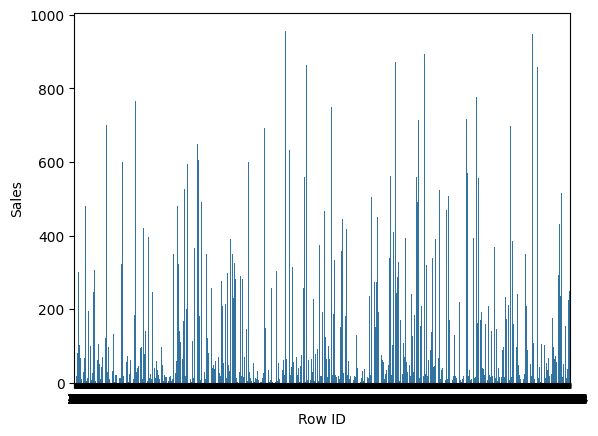

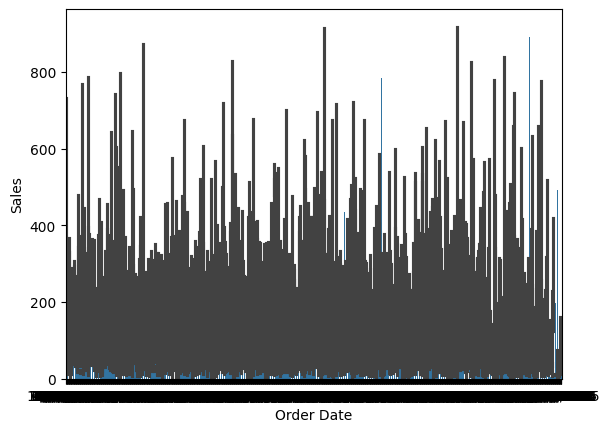

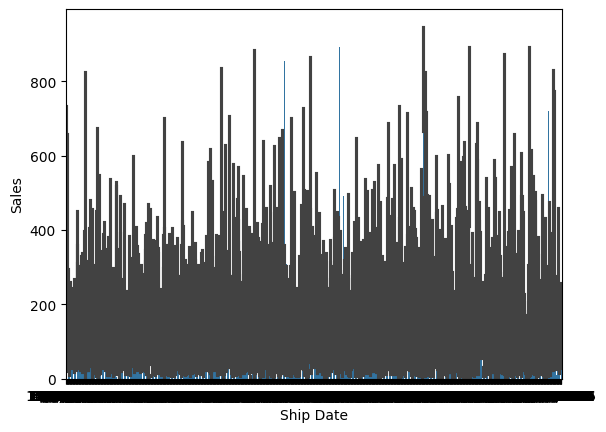

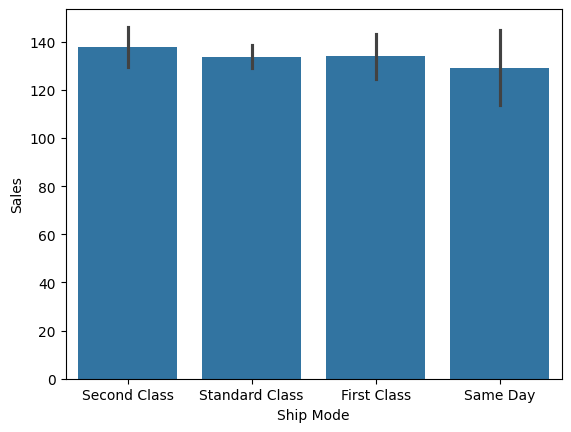

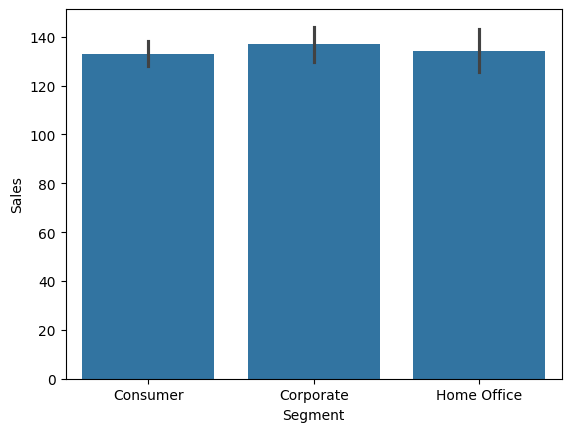

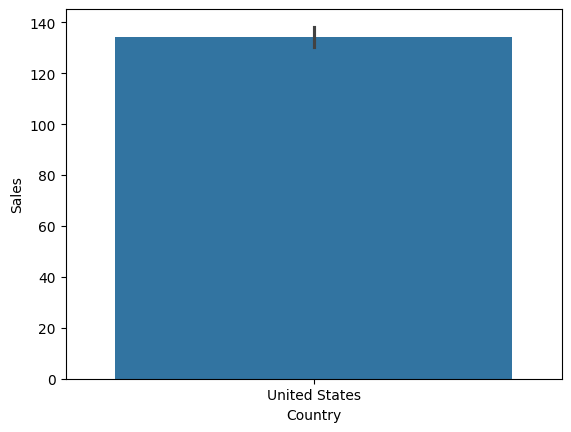

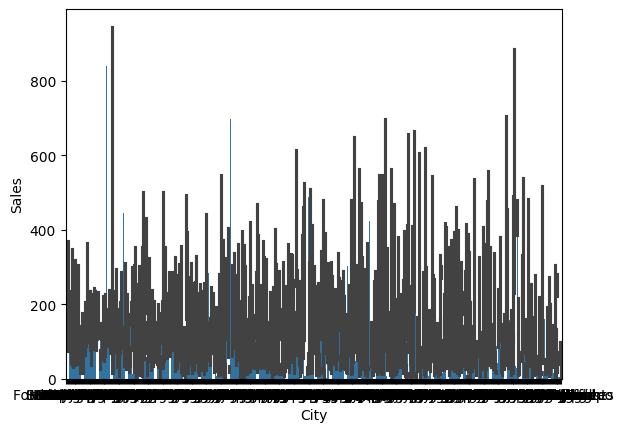

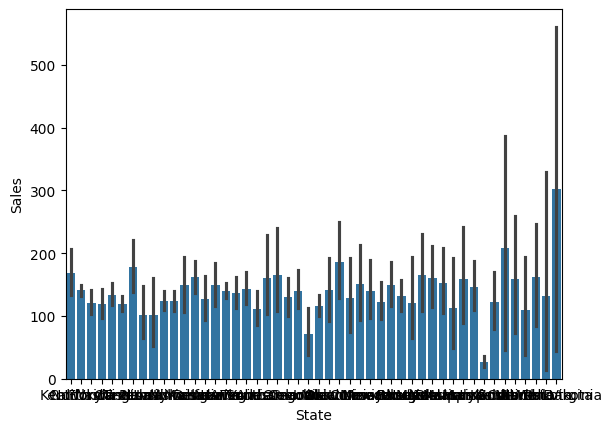

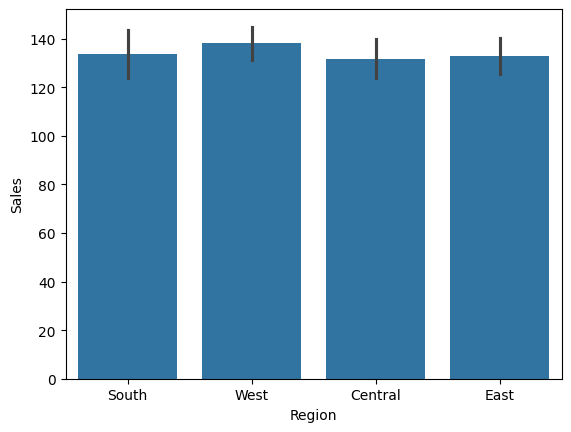

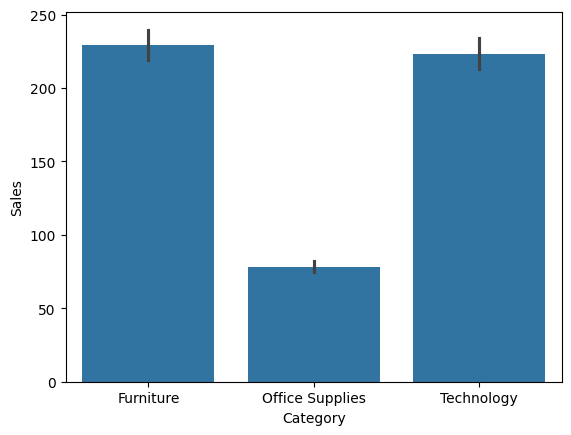

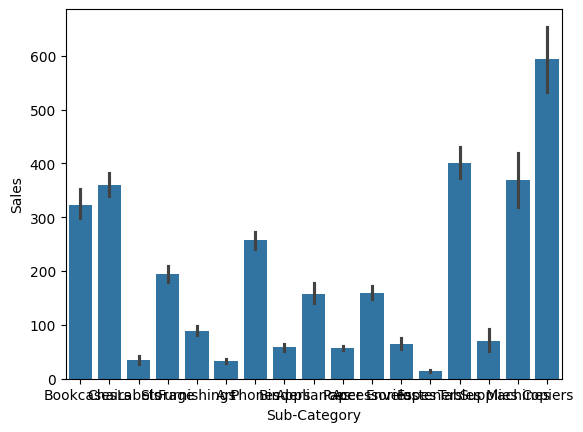

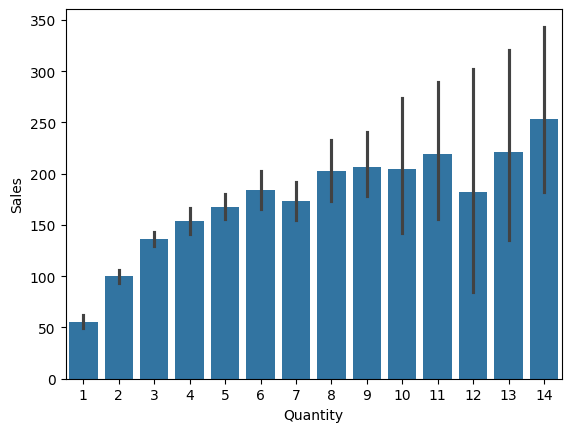

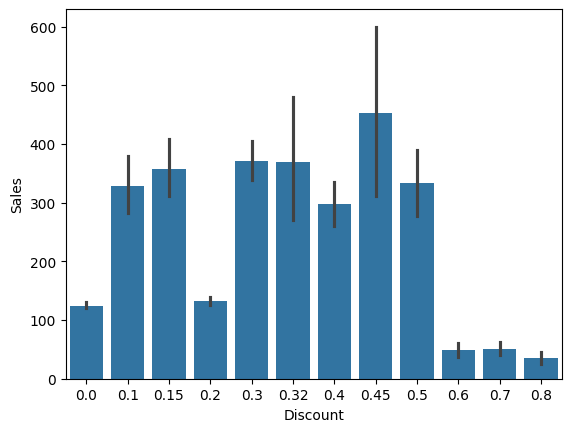

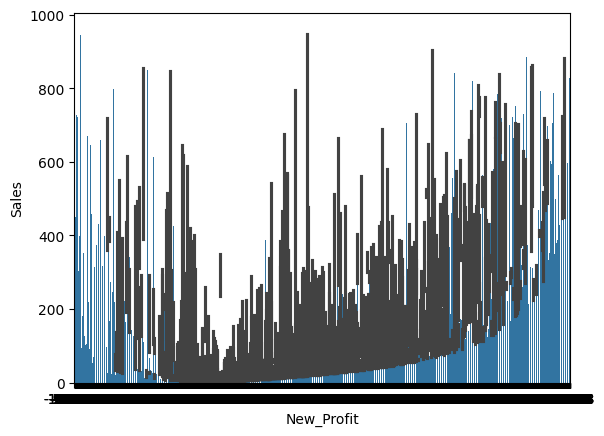

In [63]:
for col in df_cleaned.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.barplot(x=df_cleaned[col], y=df_cleaned['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

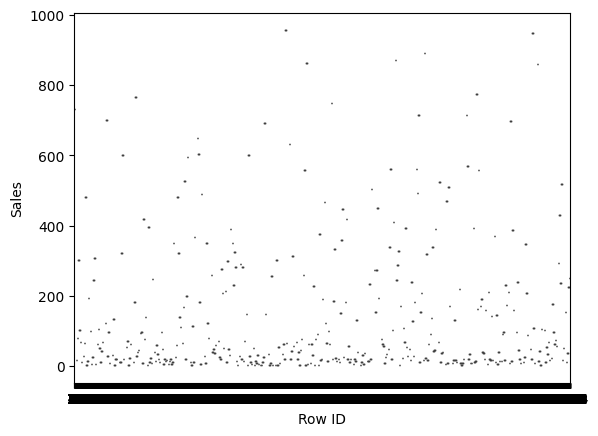

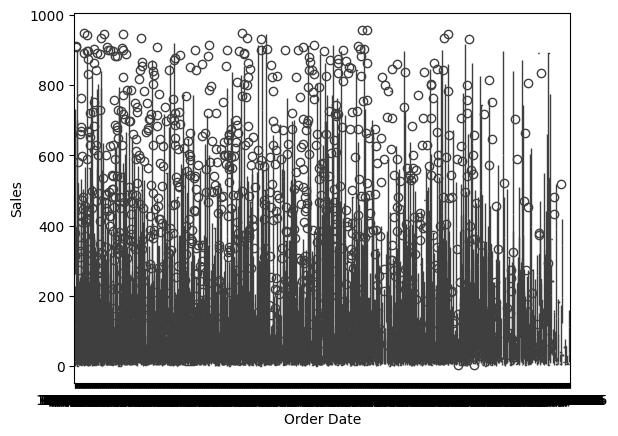

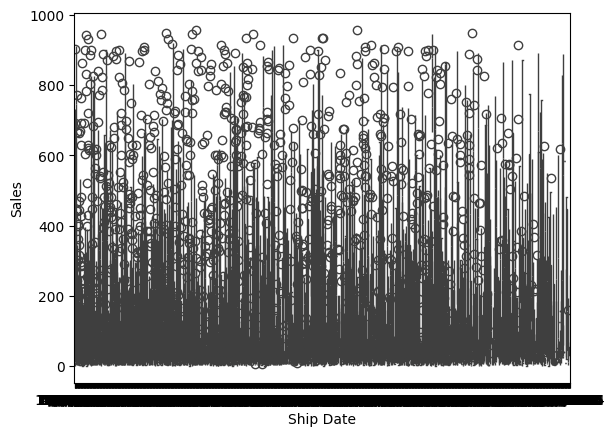

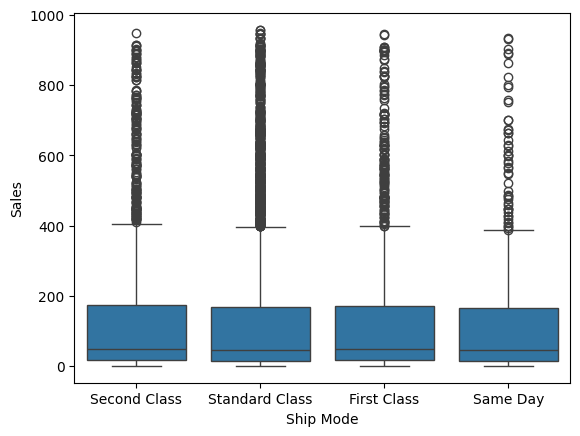

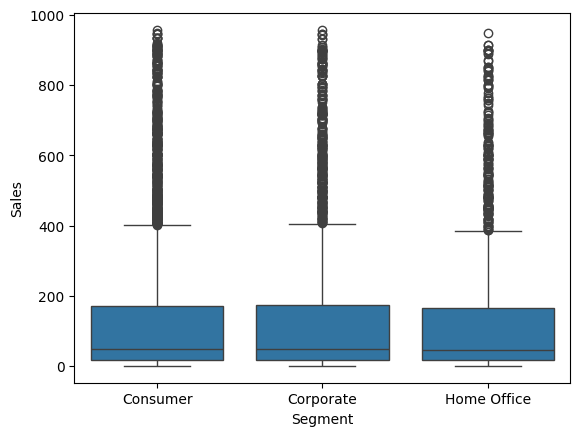

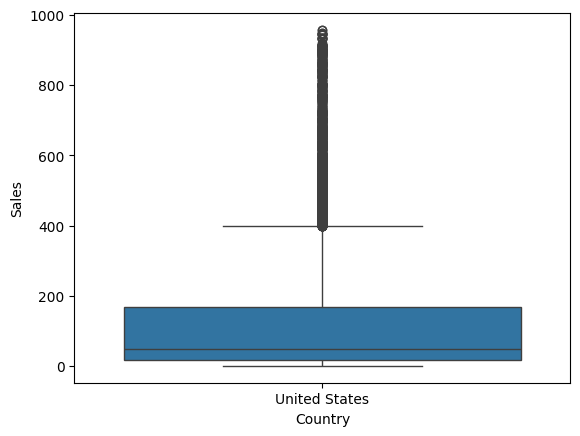

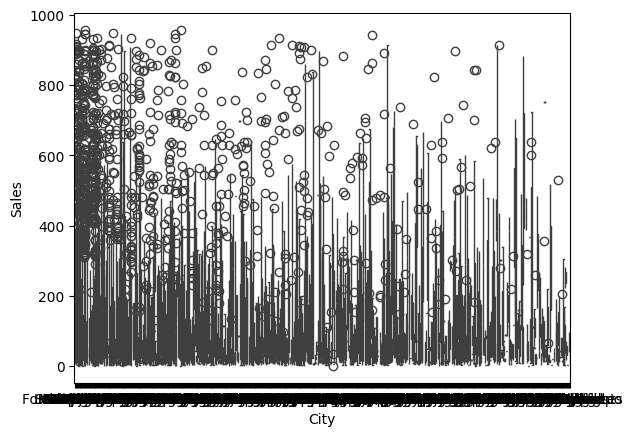

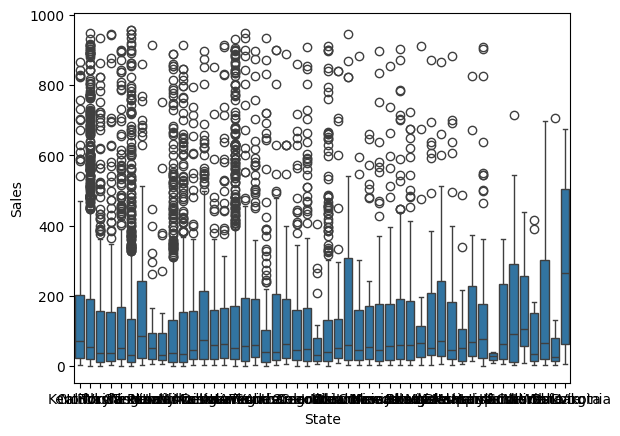

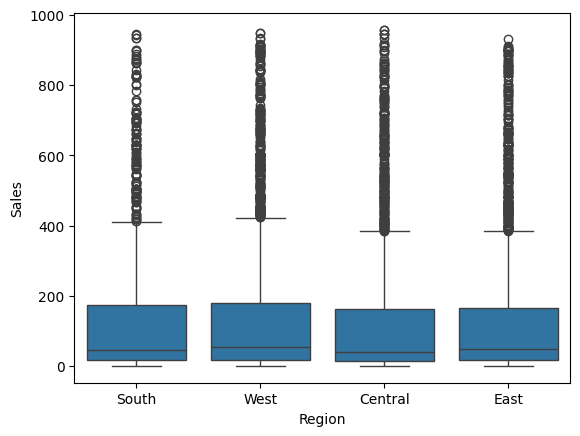

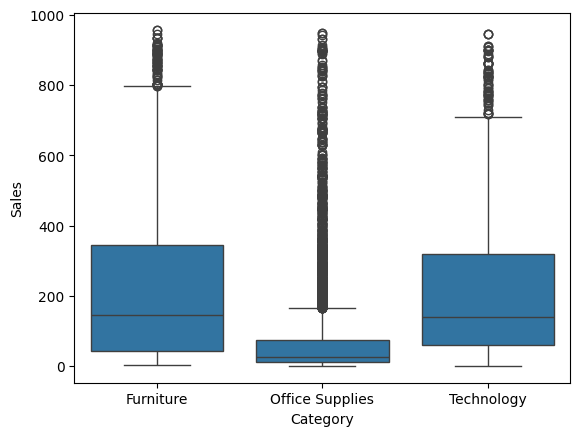

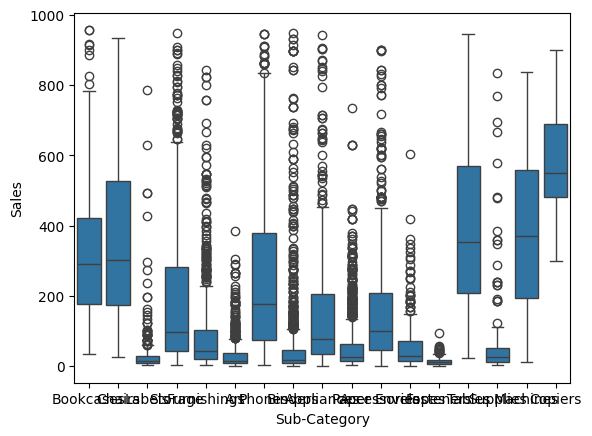

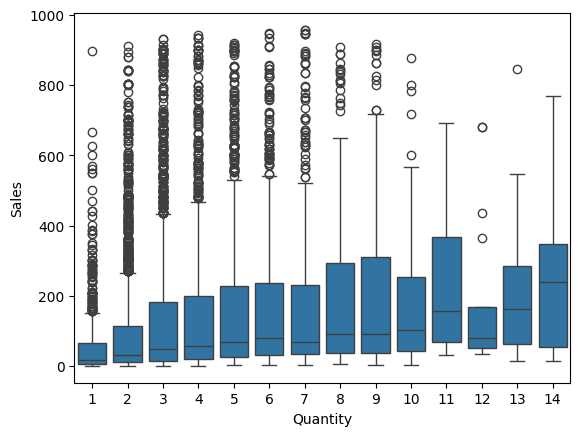

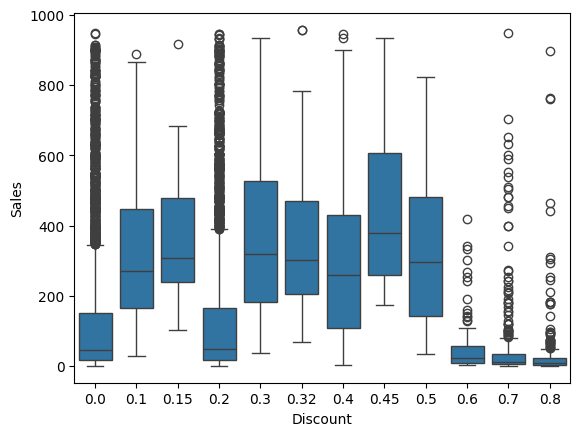

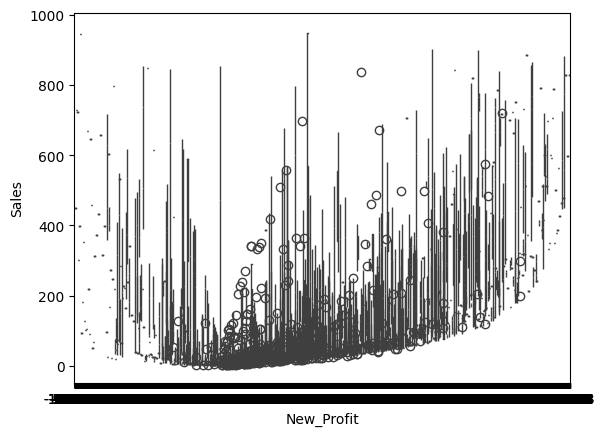

In [64]:
for col in df_cleaned.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.boxplot(x=df_cleaned[col], y=df_cleaned['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

In [65]:
df_cleaned.columns

Index(['Row ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country',
       'City', 'State', 'Region', 'Category', 'Sub-Category', 'Quantity',
       'Discount', 'New_Sales', 'New_Profit'],
      dtype='object')

In [66]:
# bins = [0, 500, df_cleaned['New_Sales'].max()]
# labels = ['<=500', '>500']
# df_cleaned['Sales_Group'] = pd.cut(df_cleaned['New_Sales'], bins=bins, labels=labels)
# df_cleaned.head()

In [67]:
# sns.boxplot(x='Ship Mode', y='Sales_Group', data=df_cleaned)

In [68]:
# Q3 = df_cleaned['New_Sales'].quantile(0.75)
# bins = [0, Q3, df_cleaned['New_Sales'].max()]
# labels = ['Normal', 'High']
# df_cleaned['Sales_Group'] = pd.cut(df_cleaned['New_Sales'], bins=bins, labels=labels)

In [69]:
# sns.boxplot(x='Ship Mode', y='Sales_Group', data=df_cleaned)

In [70]:
df_1 = df_cleaned[df_cleaned['New_Sales'] > 500]
df_2 = df_cleaned[df_cleaned['New_Sales'] <= 500]

In [71]:
df_1

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Quantity,Discount,New_Sales,New_Profit
1,2,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,3,0.00,731.94,219.58
7,8,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Technology,Phones,6,0.20,907.15,90.71
11,12,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Technology,Phones,4,0.20,911.42,68.35
16,17,11/11/2014,11/18/2014,Standard Class,Consumer,United States,Madison,Wisconsin,Central,Office Supplies,Storage,6,0.00,665.88,13.31
38,39,12/27/2015,12/31/2015,Standard Class,Home Office,United States,Houston,Texas,Central,Furniture,Bookcases,3,0.32,532.39,-46.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9879,9880,8/21/2016,8/25/2016,Standard Class,Consumer,United States,New York City,New York,East,Furniture,Chairs,7,0.10,573.17,63.68
9907,9908,9/13/2015,9/15/2015,First Class,Corporate,United States,Anaheim,California,West,Furniture,Chairs,3,0.20,717.72,71.77
9919,9920,3/15/2016,3/19/2016,Standard Class,Corporate,United States,Bryan,Texas,Central,Furniture,Chairs,5,0.30,528.42,-143.44
9931,9932,11/13/2015,11/17/2015,Standard Class,Consumer,United States,San Bernardino,California,West,Furniture,Bookcases,4,0.15,683.33,-40.20


In [72]:
df_2

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Quantity,Discount,New_Sales,New_Profit
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,2,0.0,261.95,41.91
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,2,0.0,14.62,6.87
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,2,0.2,22.36,2.51
5,6,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Furniture,Furnishings,7,0.0,48.86,14.16
6,7,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Office Supplies,Art,4,0.0,7.28,1.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,1/21/2014,1/23/2014,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings,3,0.2,25.24,4.10
9990,9991,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings,2,0.0,91.96,15.63
9991,9992,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones,2,0.2,258.57,19.39
9992,9993,2/26/2017,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,West,Office Supplies,Paper,4,0.0,29.60,13.32


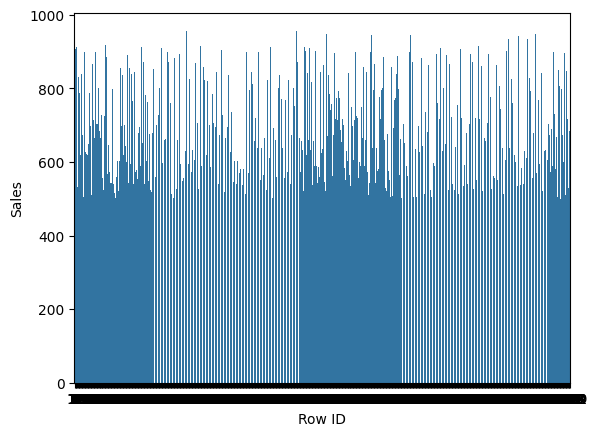

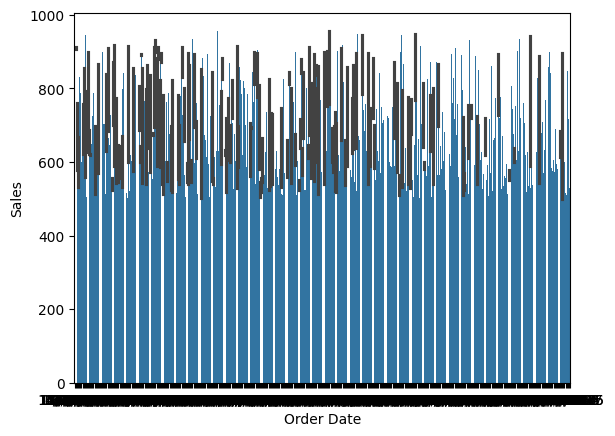

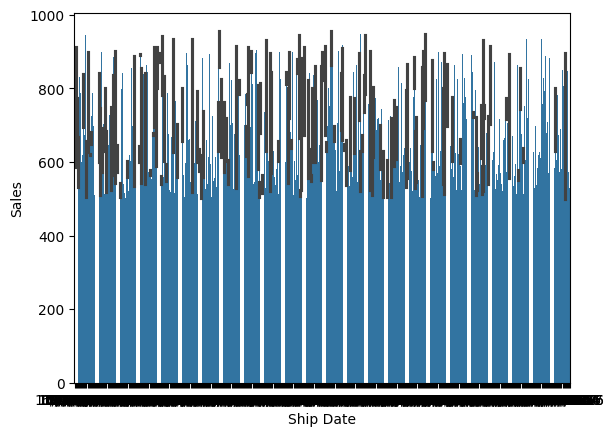

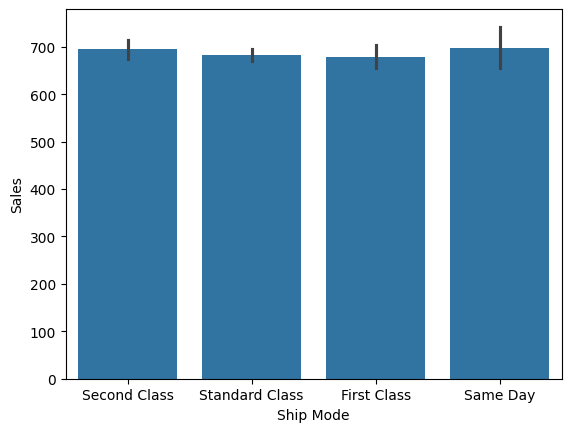

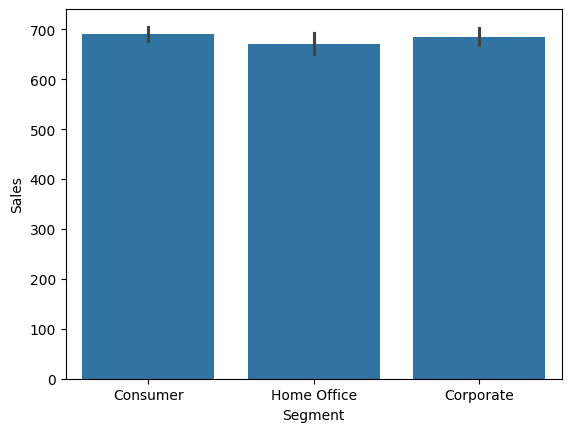

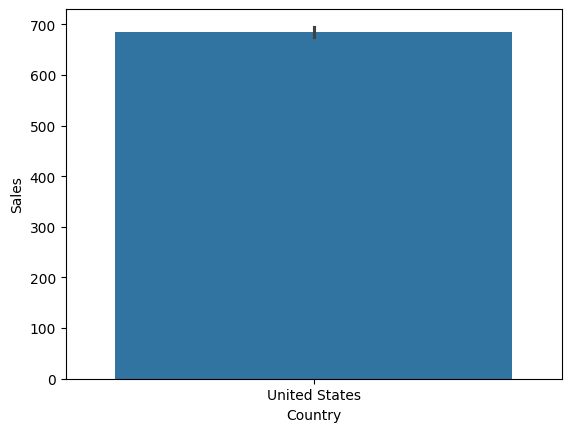

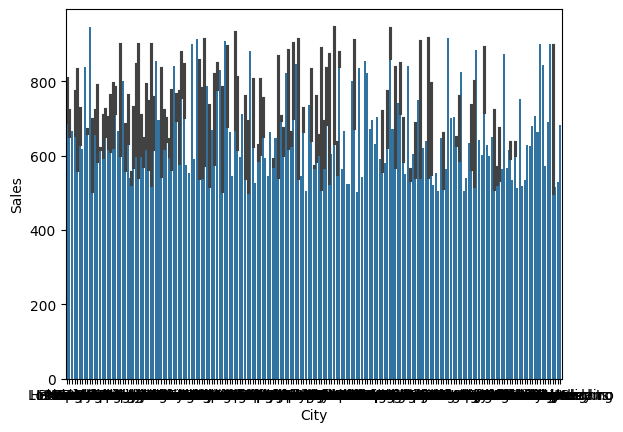

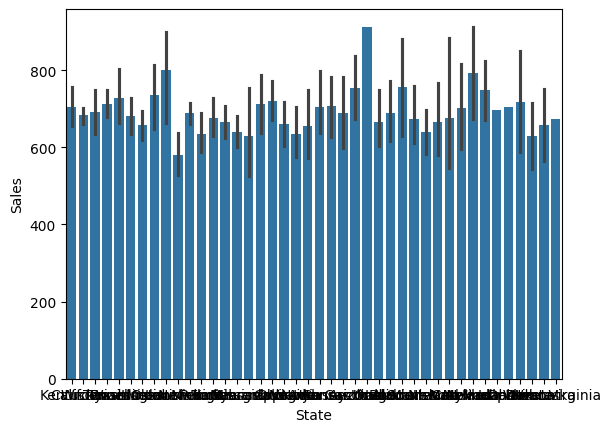

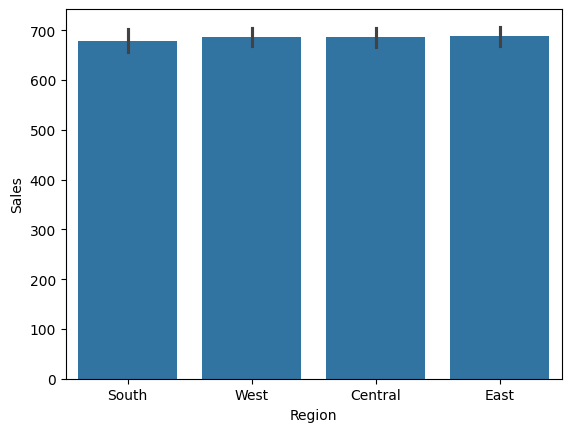

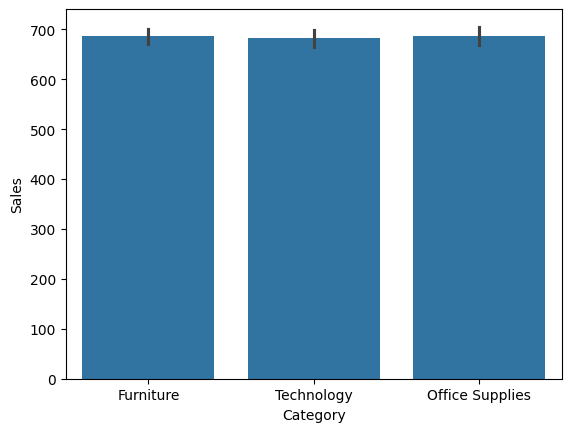

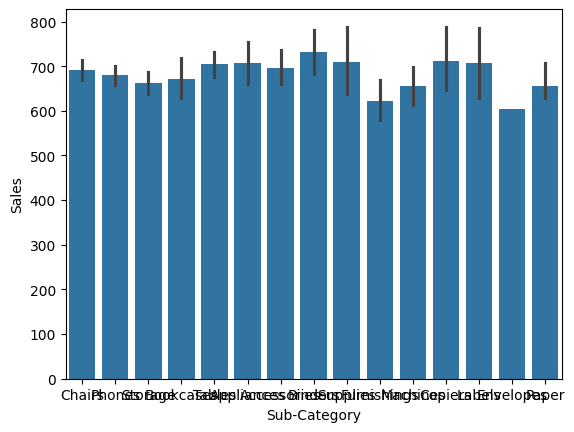

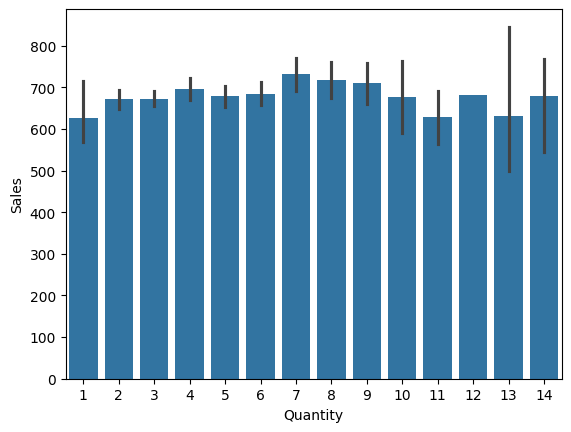

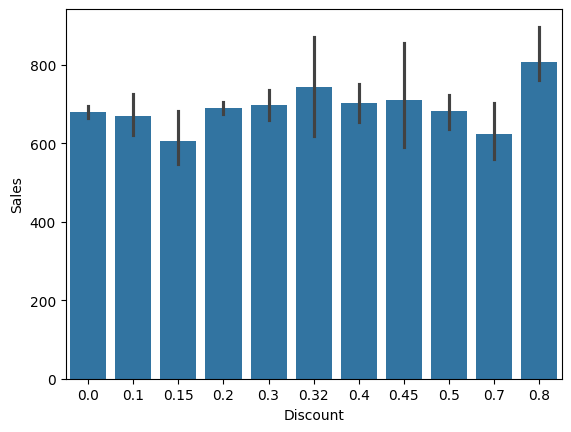

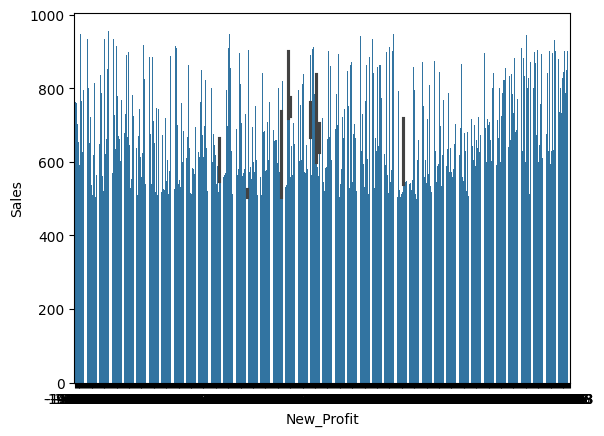

In [73]:
for col in df_1.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.barplot(x=df_1[col], y=df_1['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

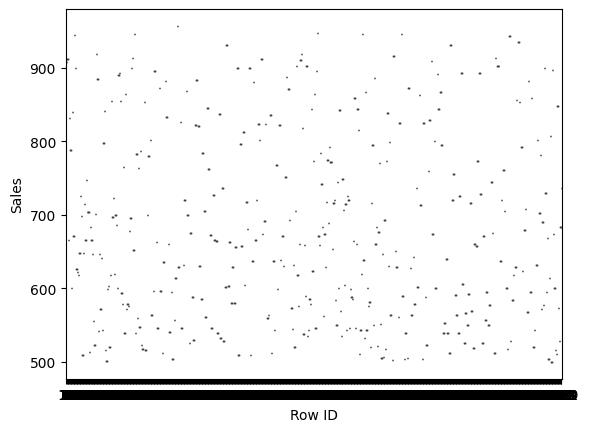

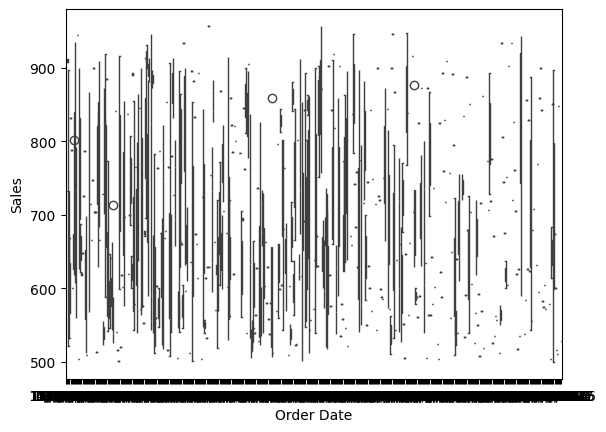

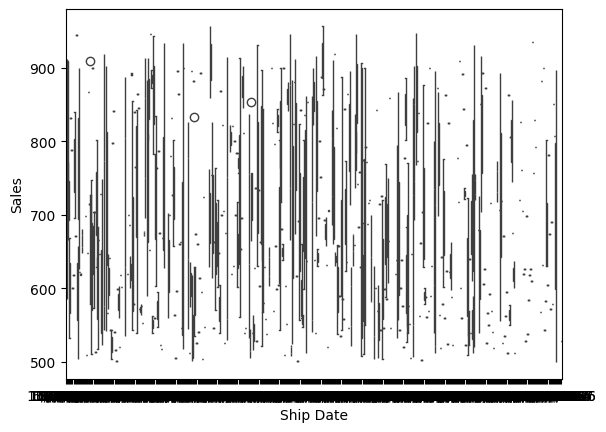

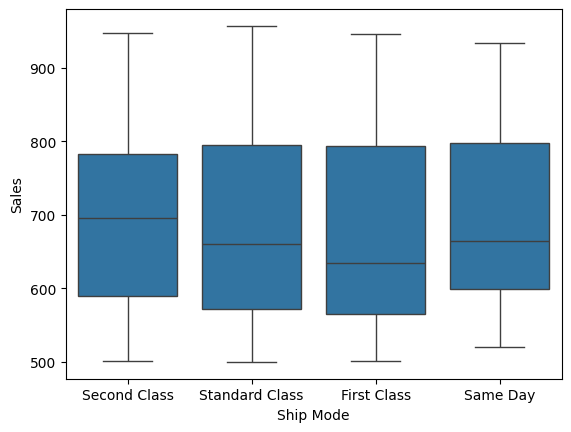

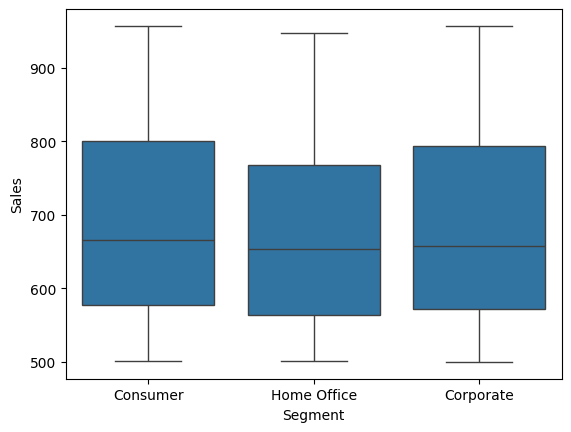

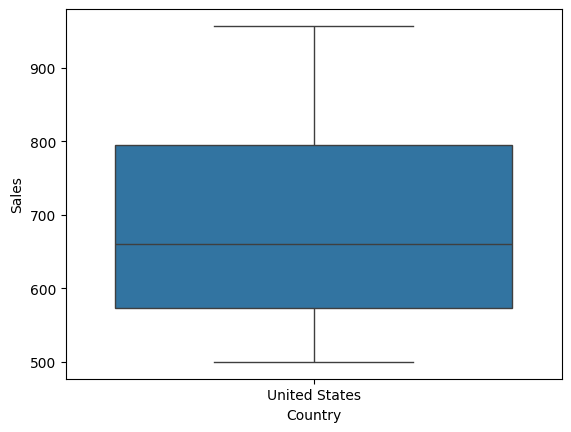

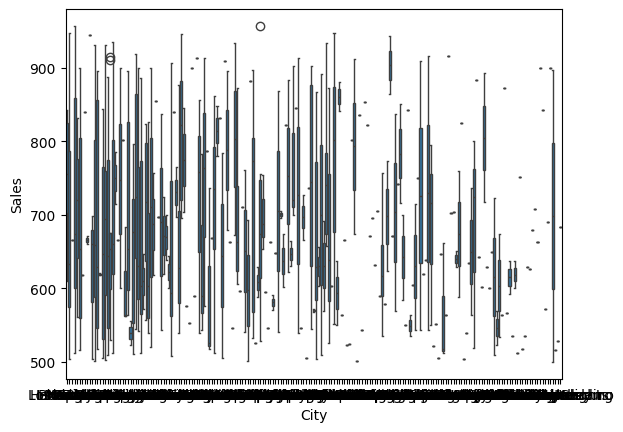

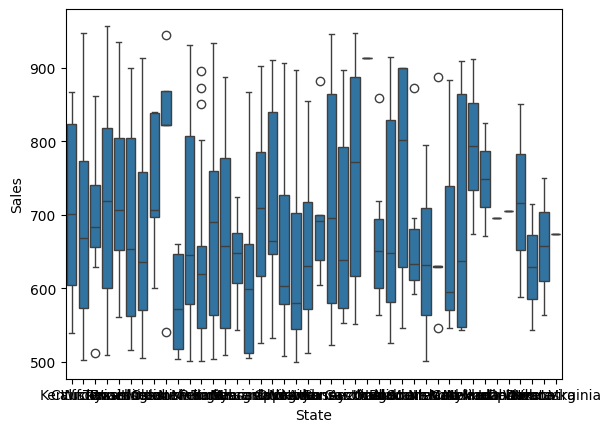

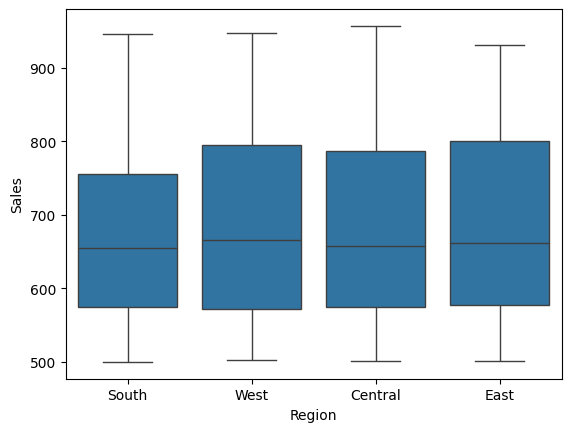

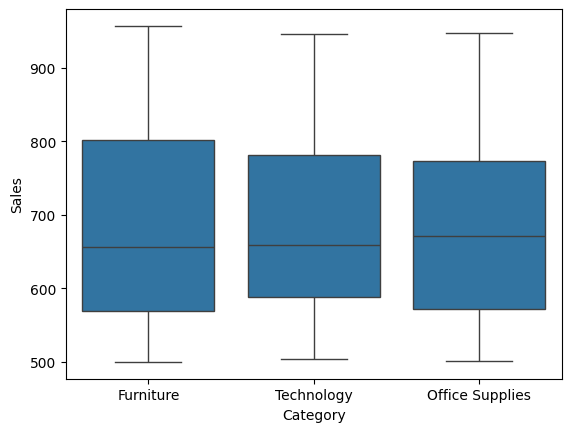

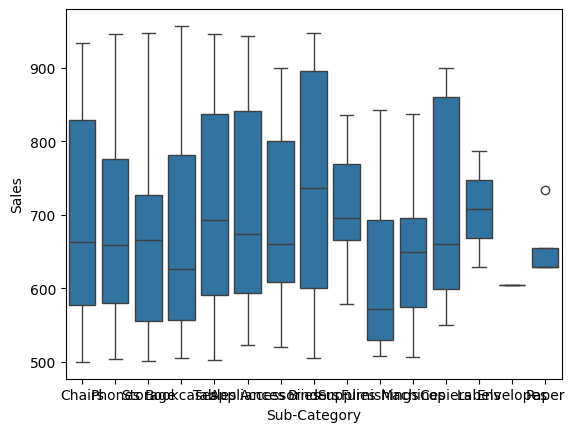

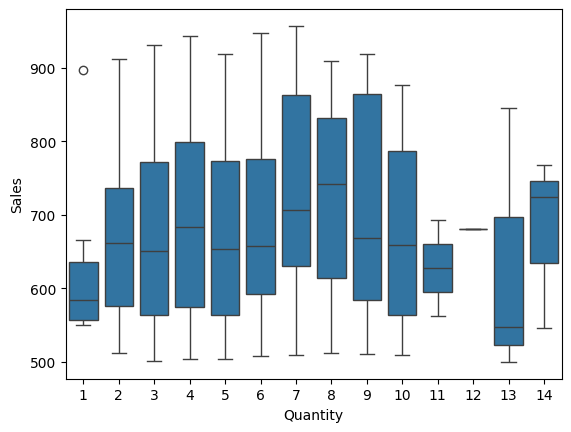

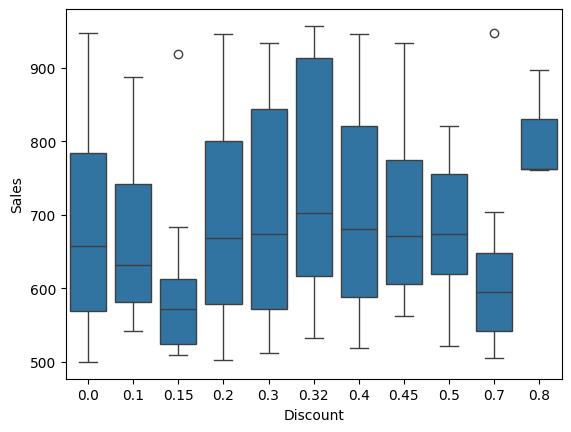

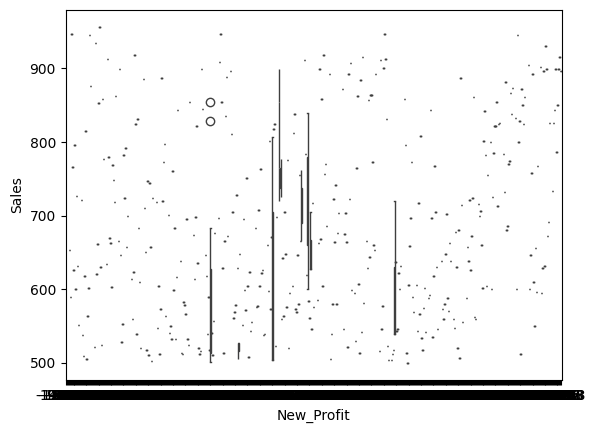

In [74]:
for col in df_1.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.boxplot(x=df_1[col], y=df_1['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

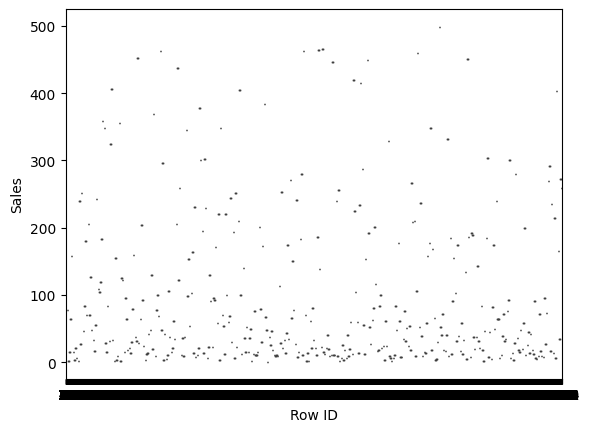

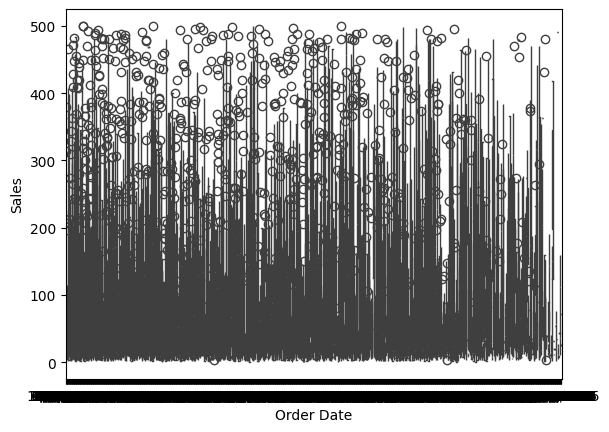

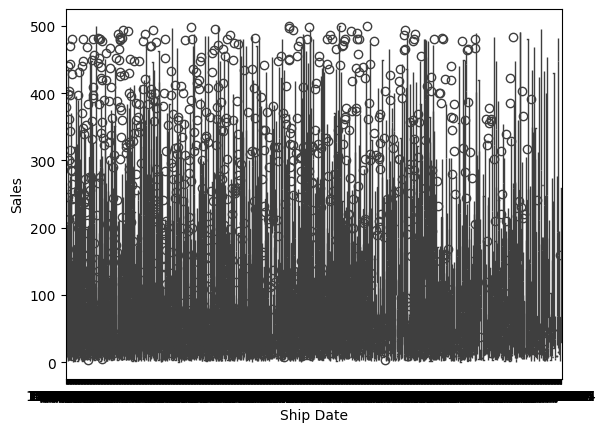

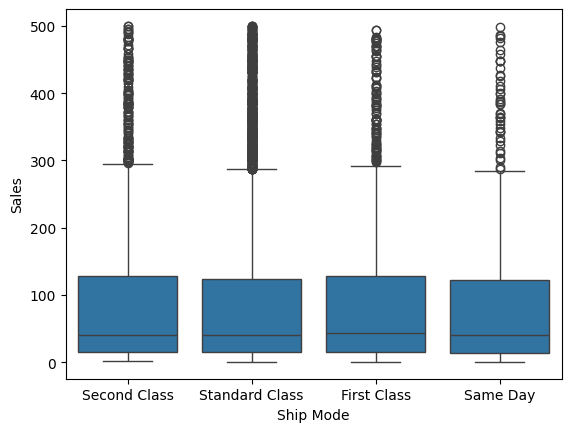

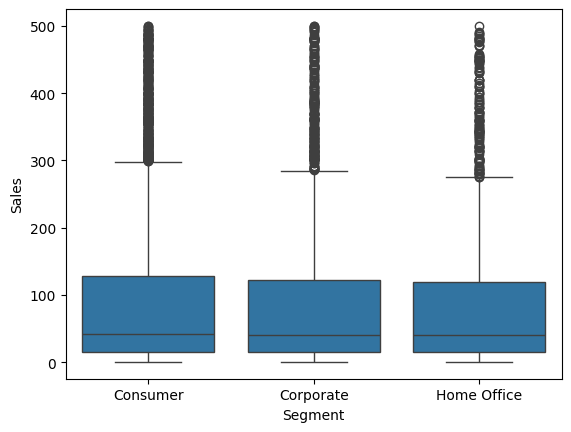

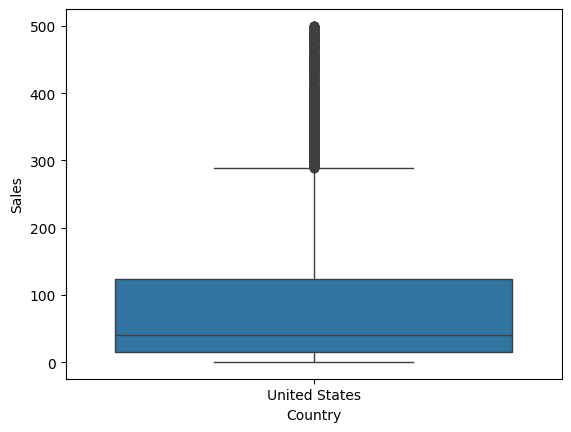

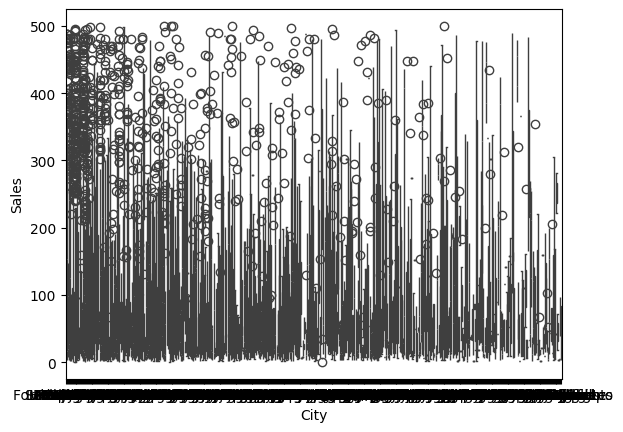

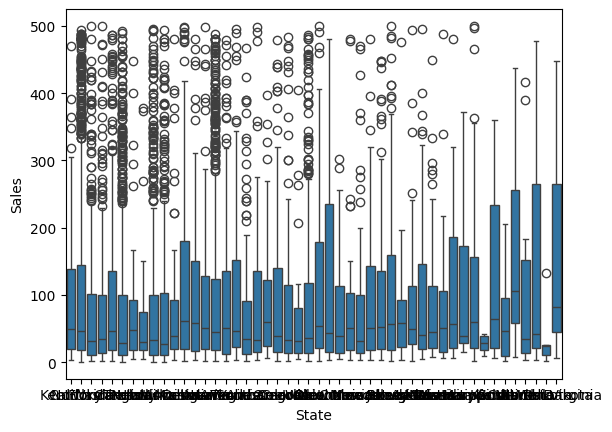

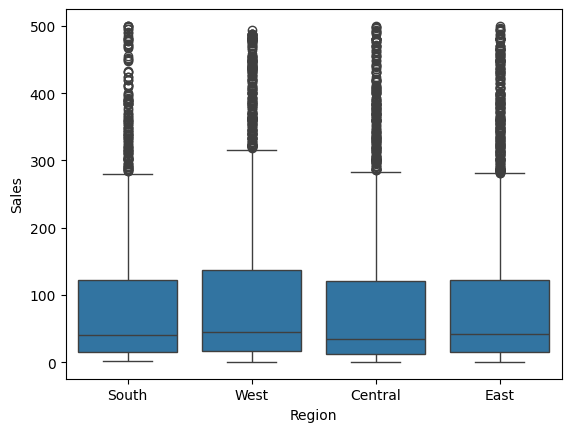

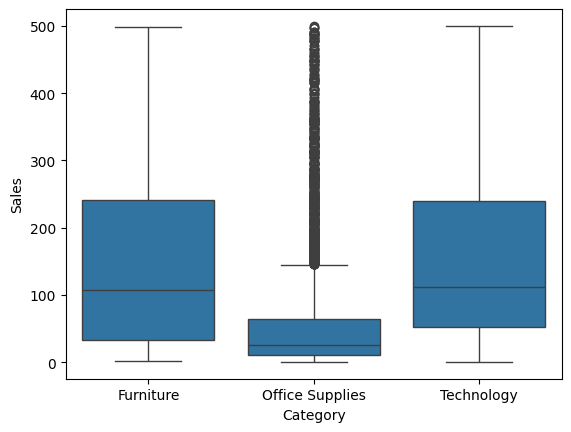

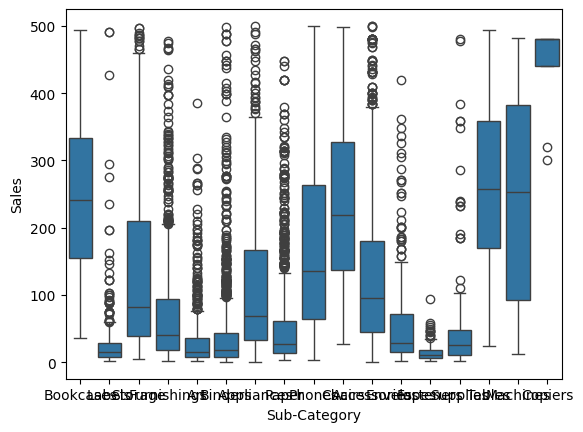

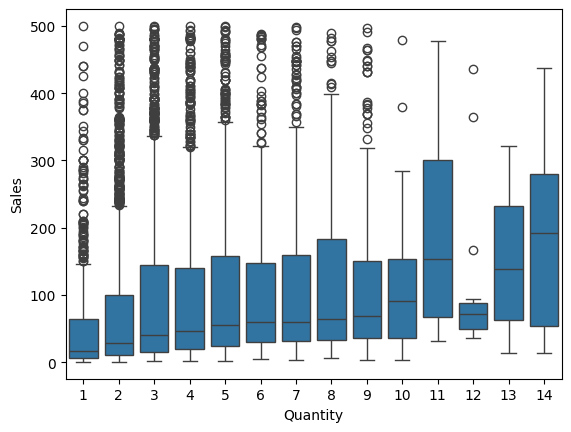

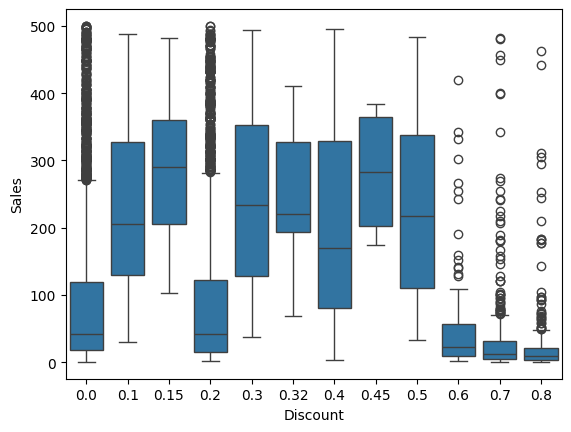

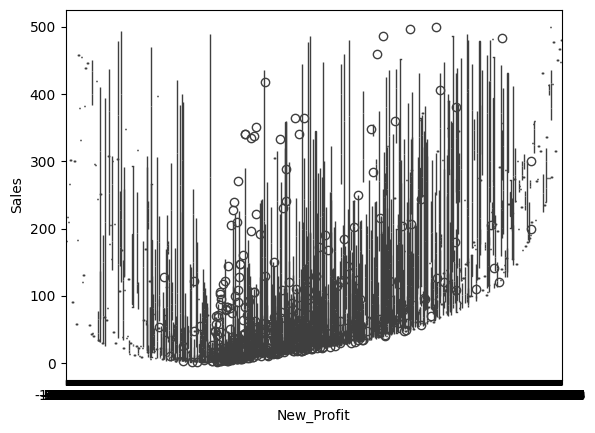

In [75]:
for col in df_2.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.boxplot(x=df_2[col], y=df_2['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

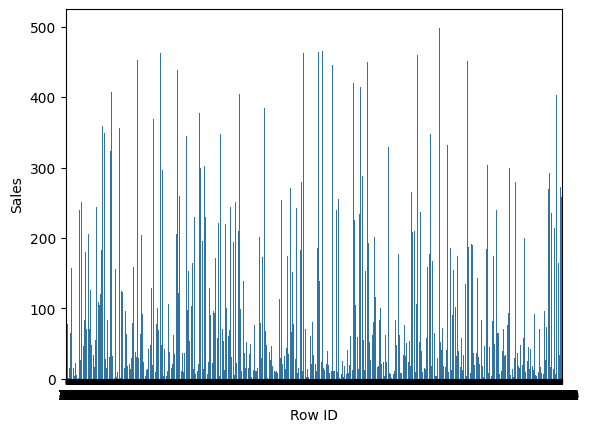

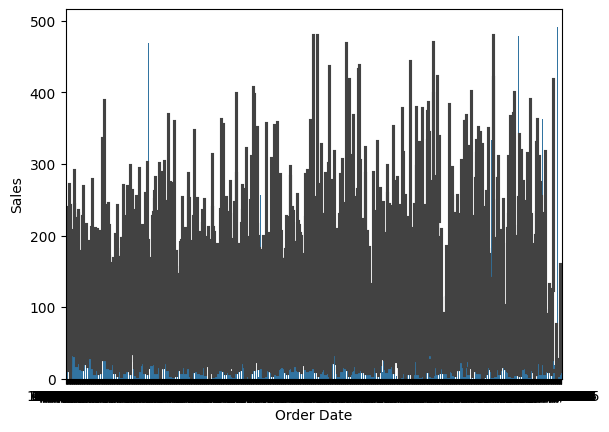

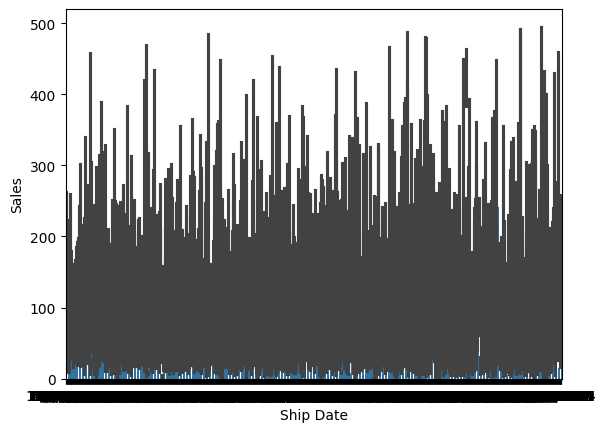

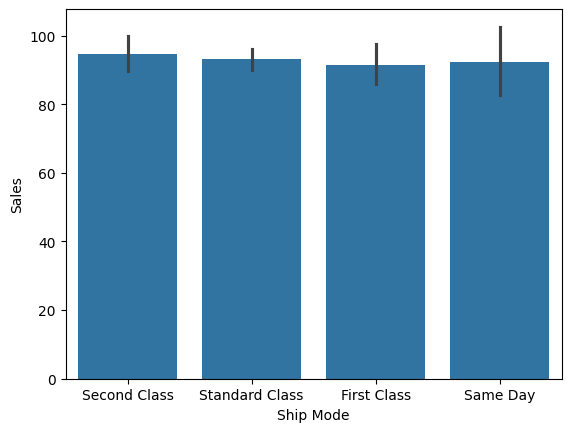

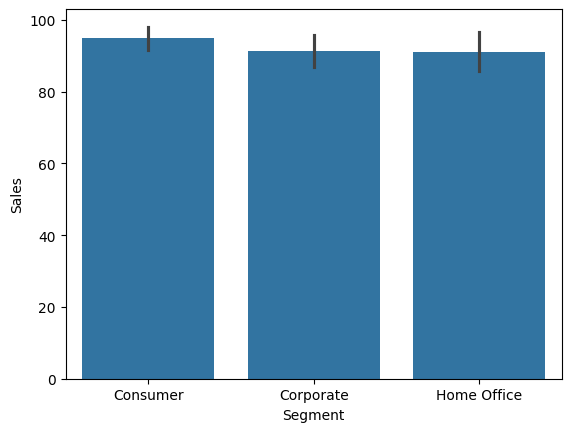

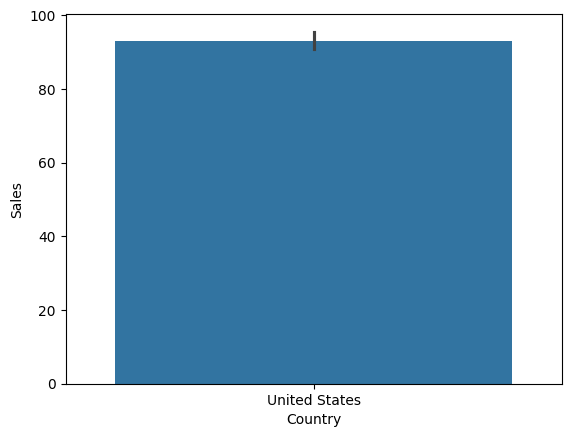

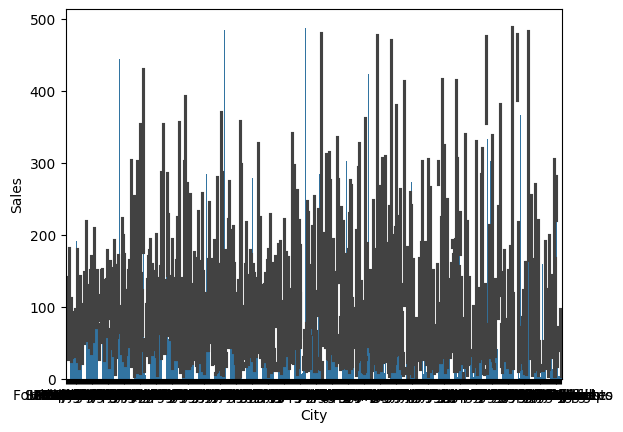

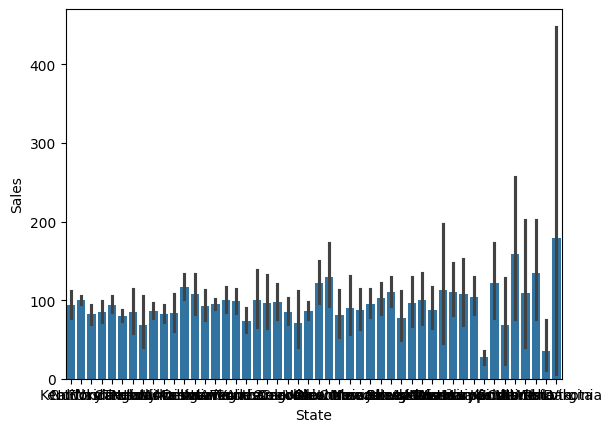

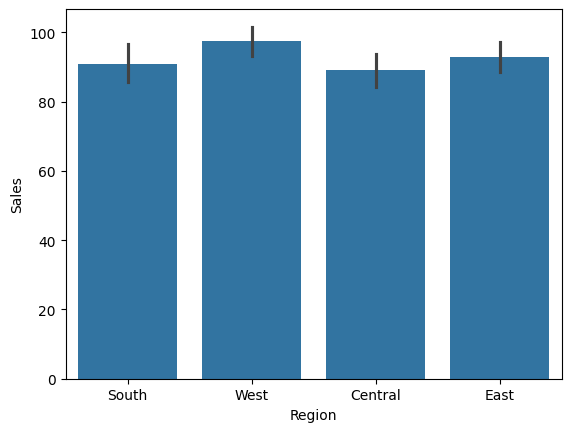

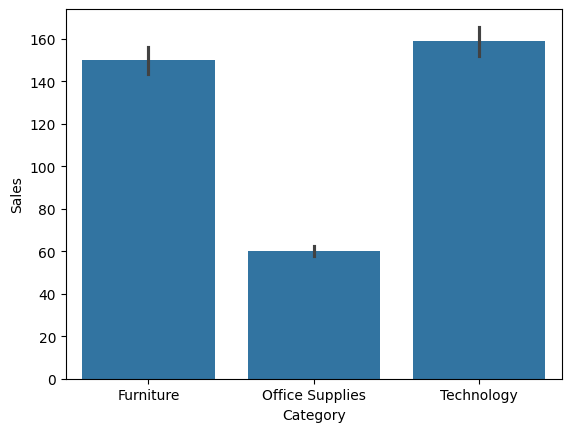

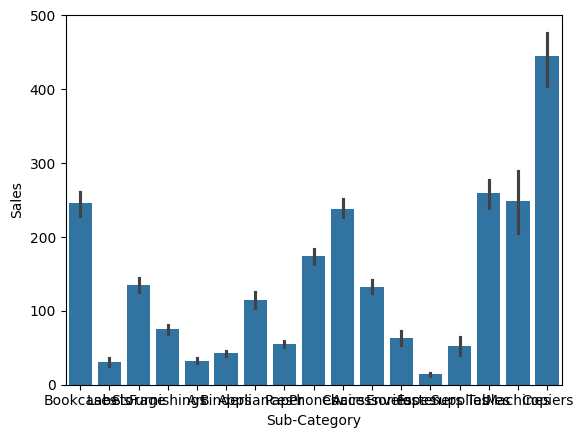

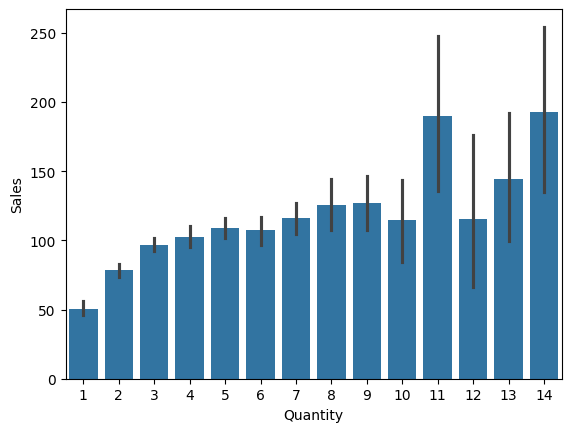

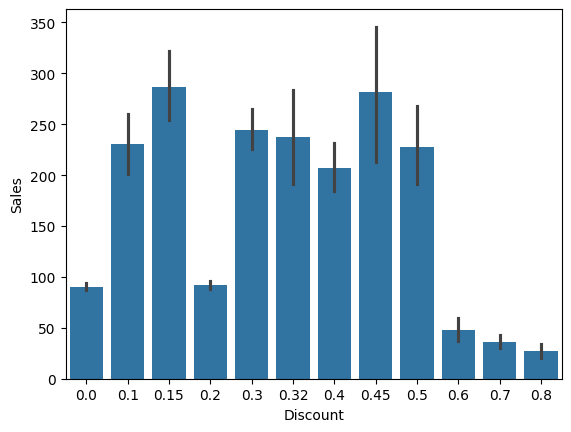

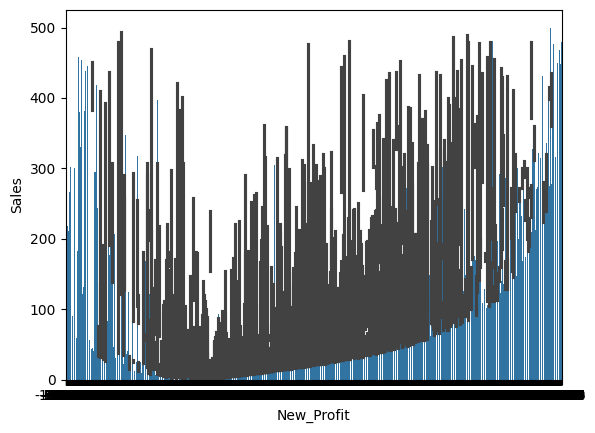

In [76]:
for col in df_2.columns:
    if col == "New_Sales":
        continue

    plt.Figure()
    sns.barplot(x=df_2[col], y=df_2['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

In [ ]:
columns_drop = ['Row ID', 'Order Date', 'Ship Date','Country','City', 'State','Sub-Category', 'Quantity','Discount', 'New_Sales', 'New_Profit']
data_Visullization_1 = df_1.drop(columns_drop, axis=1)
# Sub-Category
data_Visullization_1

,Ship Mode,Segment,Region,Category
1,Second Class,Consumer,South,Furniture
7,Standard Class,Consumer,West,Technology
11,Standard Class,Consumer,West,Technology
16,Standard Class,Consumer,Central,Office Supplies
38,Standard Class,Home Office,Central,Furniture
...,...,...,...,...
9879,Standard Class,Consumer,East,Furniture
9907,First Class,Corporate,West,Furniture
9919,Standard Class,Corporate,Central,Furniture
9931,Standard Class,Consumer,West,Furniture


In [78]:
data_Visullization_2 = df_2.drop(columns_drop, axis=1)
# Sub-Category
data_Visullization_2

,Ship Mode,Segment,Region,Category
0,Second Class,Consumer,South,Furniture
2,Second Class,Corporate,West,Office Supplies
4,Standard Class,Consumer,South,Office Supplies
5,Standard Class,Consumer,West,Furniture
6,Standard Class,Consumer,West,Office Supplies
...,...,...,...,...
9989,Second Class,Consumer,South,Furniture
9990,Standard Class,Consumer,West,Furniture
9991,Standard Class,Consumer,West,Technology
9992,Standard Class,Consumer,West,Office Supplies


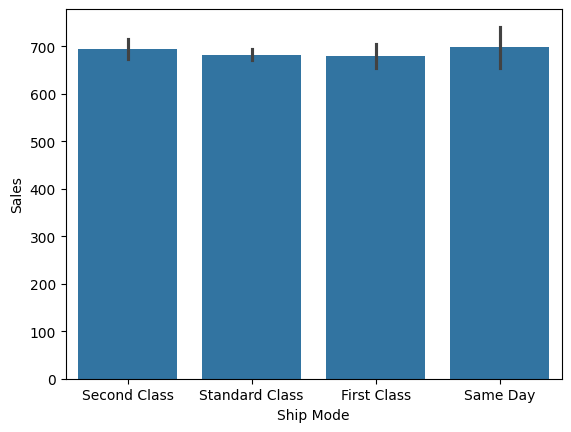

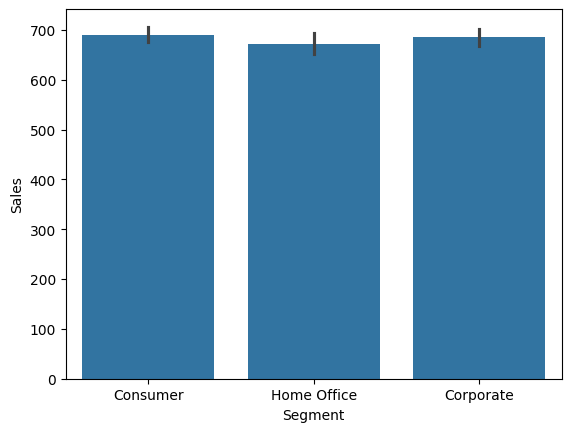

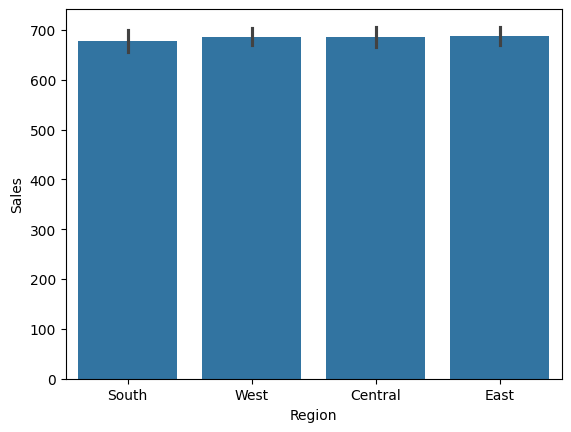

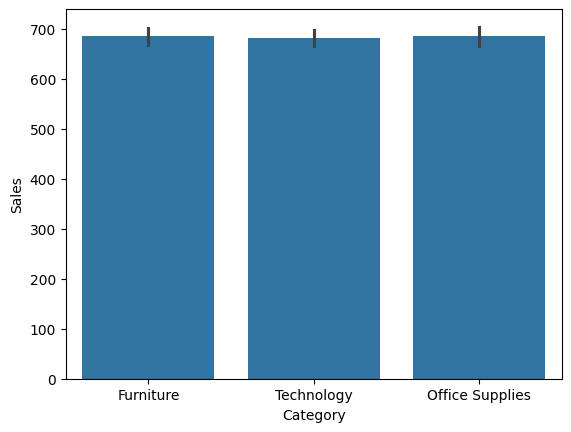

In [79]:
for col in data_Visullization_1.columns:
    plt.Figure()
    sns.barplot(x=data_Visullization_1[col], y=df_1['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

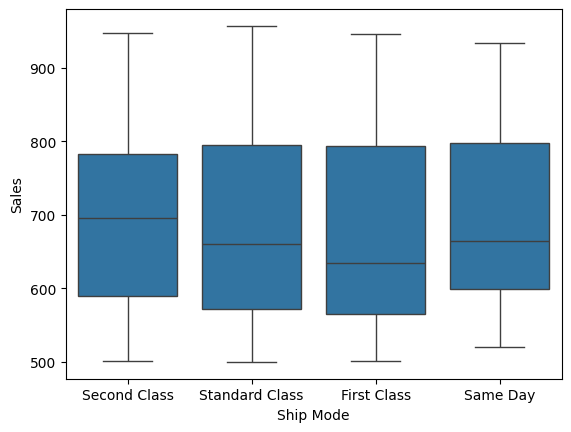

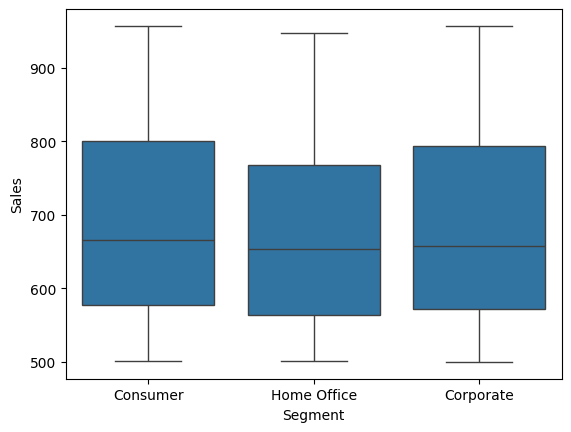

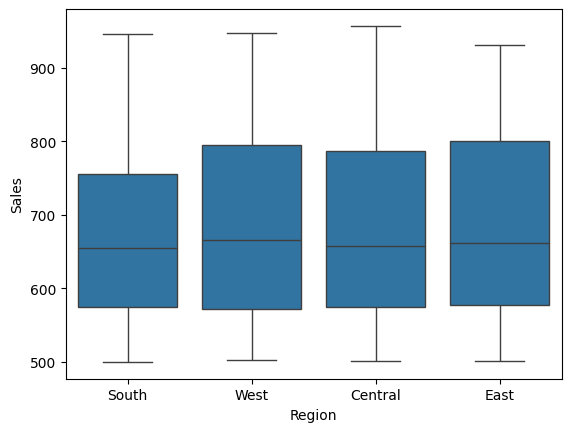

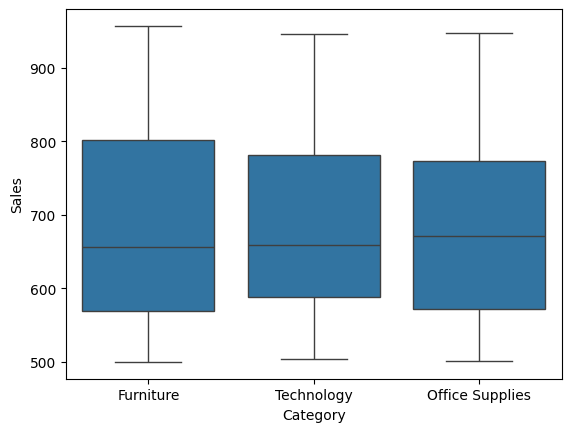

In [80]:
for col in data_Visullization_1.columns:
    plt.Figure()
    sns.boxplot(x=data_Visullization_1[col], y=df_1['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

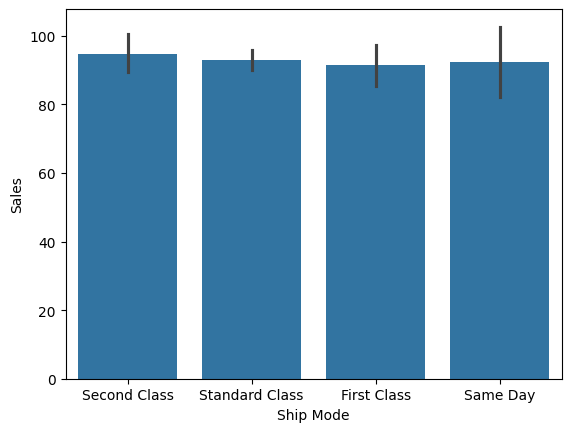

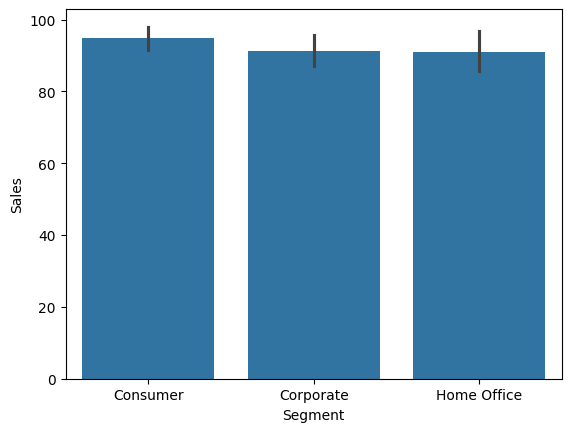

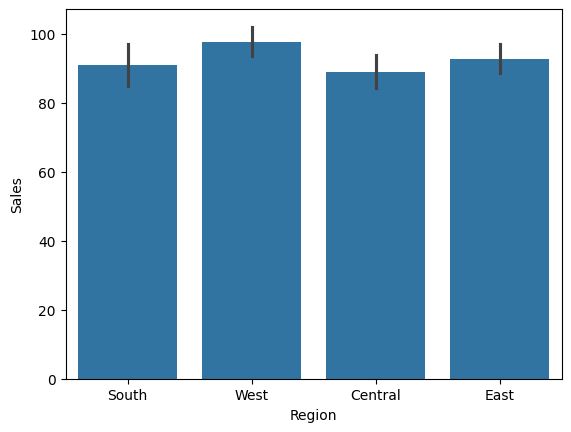

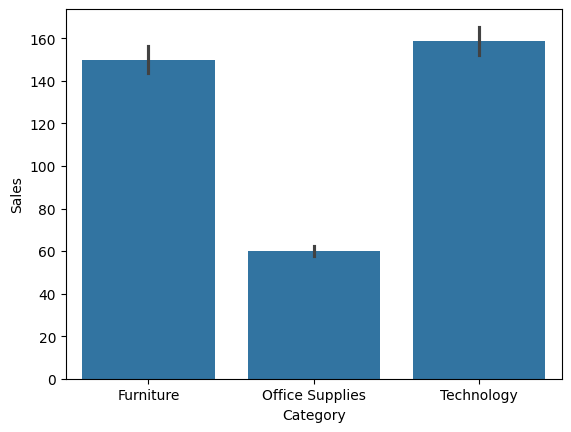

In [81]:
for col in data_Visullization_2.columns:
    plt.Figure()
    sns.barplot(x=data_Visullization_2[col], y=df_2['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

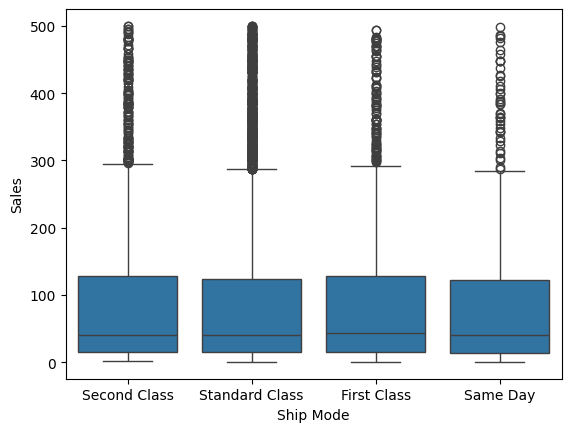

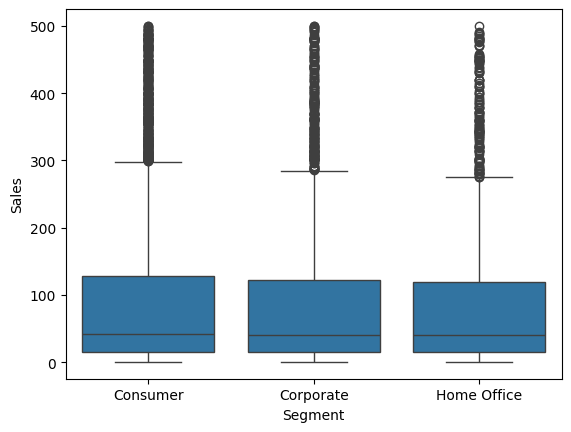

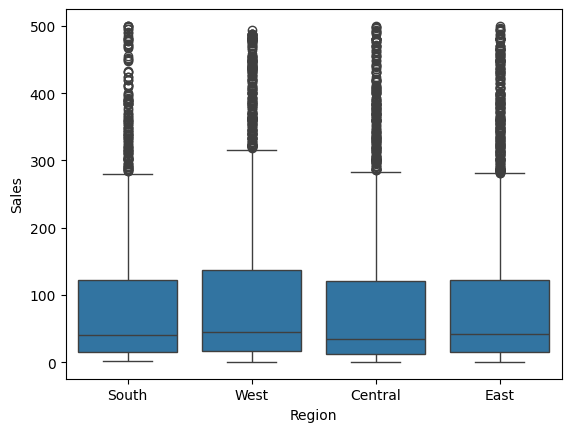

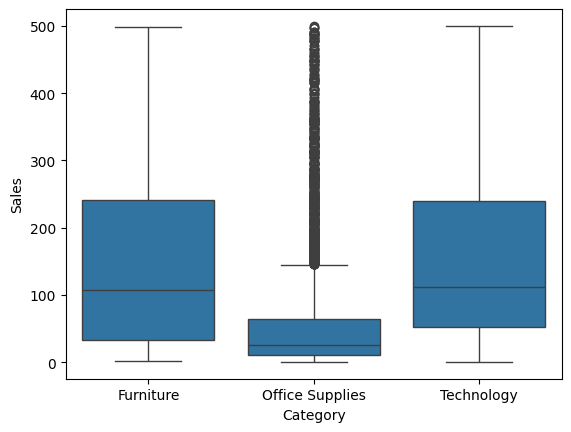

In [82]:
for col in data_Visullization_2.columns:
    plt.Figure()
    sns.boxplot(x=data_Visullization_2[col], y=df_2['New_Sales'])
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

C:\Users\a.trainee\AppData\Local\Temp\ipykernel_16652\3186397507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'])


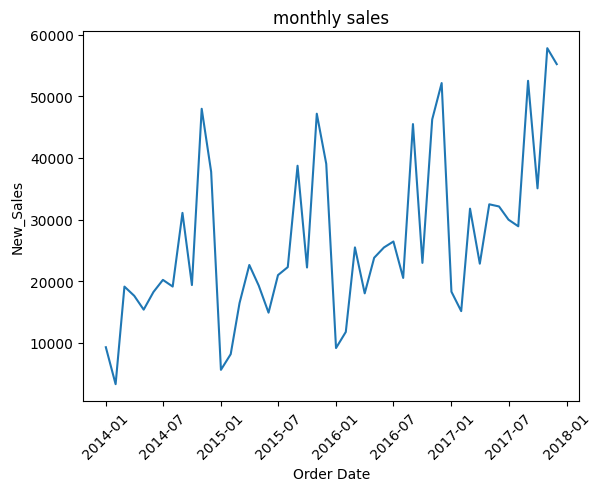

In [83]:
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'])

numeric_cols = df_cleaned.select_dtypes(include='number').columns

monthly_sales = df_cleaned.groupby(df_cleaned['Order Date'].dt.to_period('M'))[numeric_cols].sum().reset_index()

monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

sns.lineplot(x='Order Date', y='New_Sales', data=monthly_sales)
plt.xticks(rotation=45)
plt.title('monthly sales')
plt.show()

In [84]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9494 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9494 non-null   int64         
 1   Order Date    9494 non-null   datetime64[ns]
 2   Ship Date     9494 non-null   object        
 3   Ship Mode     9494 non-null   object        
 4   Segment       9494 non-null   object        
 5   Country       9494 non-null   object        
 6   City          9494 non-null   object        
 7   State         9494 non-null   object        
 8   Region        9494 non-null   object        
 9   Category      9494 non-null   object        
 10  Sub-Category  9494 non-null   object        
 11  Quantity      9494 non-null   int64         
 12  Discount      9494 non-null   float64       
 13  New_Sales     9494 non-null   float64       
 14  New_Profit    9494 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2),

C:\Users\a.trainee\AppData\Local\Temp\ipykernel_16652\552425603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'])


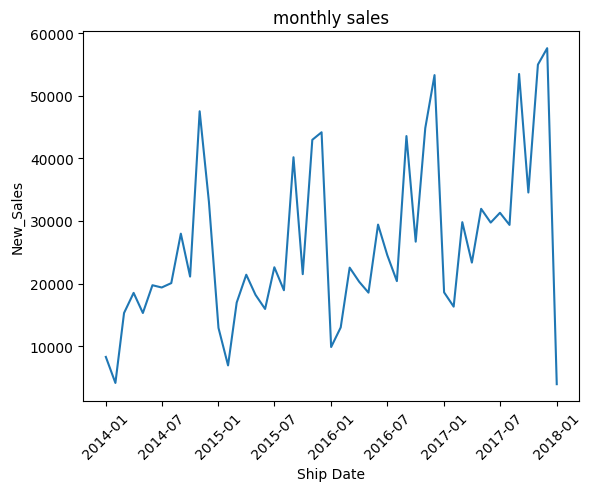

In [85]:
df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'])

numeric_cols = df_cleaned.select_dtypes(include='number').columns

monthly_sales = df_cleaned.groupby(df_cleaned['Ship Date'].dt.to_period('M'))[numeric_cols].sum().reset_index()

monthly_sales['Ship Date'] = monthly_sales['Ship Date'].dt.to_timestamp()

sns.lineplot(x='Ship Date', y='New_Sales', data=monthly_sales)
plt.xticks(rotation=45)
plt.title('monthly sales')
plt.show()

Feature Enhineering

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [87]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [102]:
df_1['Sub-Category'].value_counts()


Sub-Category
Chairs         145
Phones         133
Storage         91
Tables          81
Bookcases       37
Accessories     35
Binders         35
Appliances      32
Furnishings     25
Machines        21
Copiers         15
Supplies         5
Paper            4
Labels           2
Envelopes        1
Name: count, dtype: int64

In [101]:
df_2['Sub-Category'].value_counts()

Sub-Category
Binders        1443
Paper          1366
Furnishings     926
Art             795
Accessories     708
Storage         704
Phones          681
Appliances      411
Chairs          390
Labels          362
Envelopes       253
Fasteners       217
Supplies        176
Tables          173
Bookcases       165
Machines         50
Copiers          12
Name: count, dtype: int64

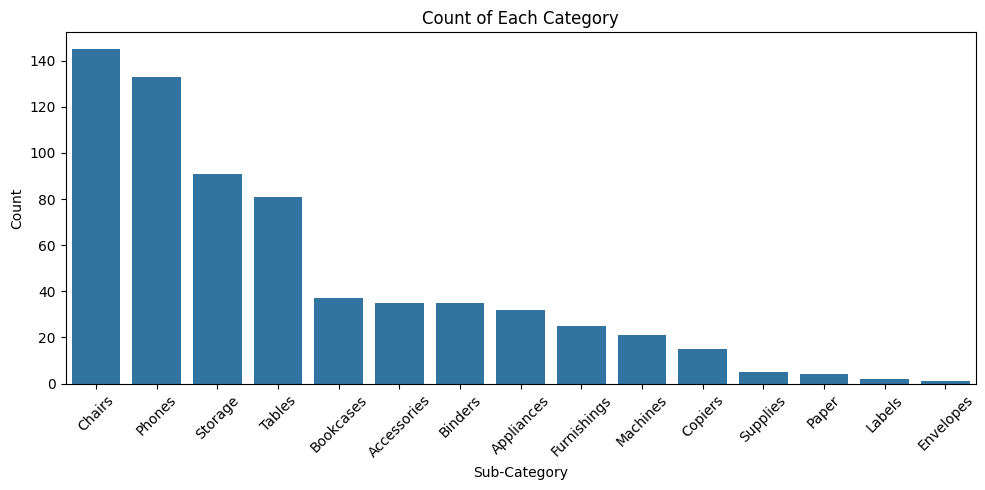

In [93]:
plt.figure(figsize=(10,5))
sns.countplot(x='Sub-Category', data=df_1, order=df_1['Sub-Category'].value_counts().index)
plt.title('Count of Each Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
df_2.head()

,Row ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Quantity,Discount,New_Sales,New_Profit
0,1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,2,0.0,261.95,41.91
2,3,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,2,0.0,14.62,6.87
4,5,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,2,0.2,22.36,2.51
5,6,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Furniture,Furnishings,7,0.0,48.86,14.16
6,7,6/9/2014,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,West,Office Supplies,Art,4,0.0,7.28,1.96


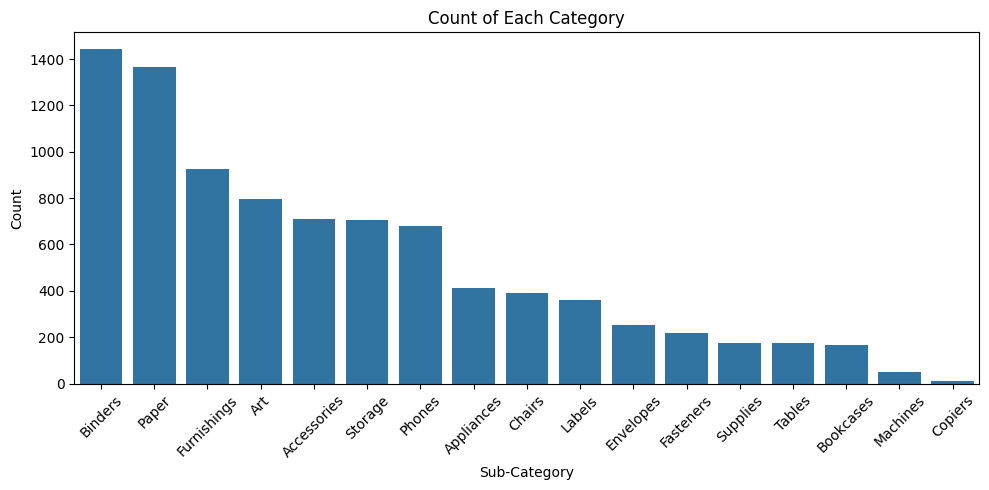

In [98]:
plt.figure(figsize=(10,5))
sns.countplot(x='Sub-Category', data=df_2, order=df_2['Sub-Category'].value_counts().index)
plt.title('Count of Each Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()